# Phát Hiện Bất Thường Theo Luật Nghiệp Vụ dựa trên Session người dùng trong web thương mại điện tử

## RetailRocket E-Commerce Dataset

Dataset: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset

Đơn vị phân tích chính là `session_id`, được tạo từ `visitorid` và khoảng nghỉ 30 phút giữa hai sự kiện liên tiếp. Dataset không có nhãn bất thường thật, vì vậy nhãn `is_anomaly_rule` và `anomaly_types` là pseudo-label do nhóm thiết kế bằng luật nghiệp vụ.

## Hệ thống business rules và anomaly types

| Mã | Anomaly type | Mô tả nghiệp vụ | Dấu hiệu chính trong notebook |
| --- | --- | --- | --- |
| BR01 | Bot scraper | Session có hành vi duyệt tự động hoặc quét dữ liệu nhanh. | Nhiều event trong session hoặc tốc độ event/phút cao. |
| BR02 | Ghost buyer | Có giao dịch nhưng không có bước thêm giỏ trong cùng session. | `transaction > 0` và `addtocart = 0`. |
| BR03 | Click fraud | Xem nhiều sản phẩm nhưng không có ý định mua hoặc thêm giỏ. | Nhiều `view`, không có `addtocart`, không có `transaction`. |
| BR04 | Rapid-fire | Các thao tác diễn ra quá sát nhau, giống bot/script. | Có event liên tiếp dưới 1 giây hoặc tỉ lệ rapid-fire cao. |
| BR05 | Night crawler | Session hoạt động chủ yếu vào khung giờ đêm. | Tỉ lệ event 0h-5h cao và session đủ số event tối thiểu. |
| BR06 | Item hoarding | Thêm cùng một sản phẩm vào giỏ nhiều lần trong một session. | `max_same_item_atc` vượt ngưỡng. |
| BR07 | Session bomb | Session xem/quét quá nhiều item khác nhau. | `unique_items` cao. |
| BR08 | Sequence violation | Thứ tự hành vi bất thường: mua trước khi xem/thêm giỏ cùng item. | `transaction` xuất hiện trước `view/addtocart` của cùng item trong session. |
| BR09 | Transaction burst | Session có số lượng giao dịch cao bất thường. | `n_transaction` vượt ngưỡng. |
| BR10 | Cart abandonment | Thêm nhiều sản phẩm vào giỏ nhưng không giao dịch. | `n_addtocart` cao và `n_transaction = 0`. |
| BR11 | Repeated view spam | Xem lặp lại cùng một item quá nhiều lần. | `max_same_item_view` vượt ngưỡng. |
| BR12 | Category scanning | Quét nhiều nhóm danh mục sản phẩm trong một session. | `unique_categories` cao nếu dữ liệu category khả dụng. |

Các rule này dùng để gắn nhãn multi-label cho session. Một session có thể vừa là `Bot scraper`, vừa là `Rapid-fire`, vừa là `Session bomb`. Các thuật toán ML dùng pseudo-label này để so sánh/mô phỏng, không được diễn giải như nhãn gian lận thật.

Phần mô hình được chia thành `train`, `validation`, `test`. Validation dùng để chọn threshold dự đoán; test dùng để báo cáo kết quả cuối.


## Phân công thuật toán

| Thành viên | Thuật toán | Loại | Vai trò trong đồ án |
| --- | --- | --- | --- |
| Đình Tuấn | XGBoost | Phân loại có giám sát | Mô hình boosting mạnh, xử lý dữ liệu phi tuyến và mất cân bằng lớp |
| Lê Văn Anh | Decision Tree | Phân loại có giám sát | Mô hình dễ giải thích, minh họa được luật quyết định |
| Tuấn Anh | Random Forest | Phân loại có giám sát | Ensemble nhiều cây, ổn định hơn cây đơn và có feature importance |
| Thủy | LightGBM | Phân loại có giám sát | Gradient boosting leaf-wise, nhanh và hiệu quả trên dữ liệu dạng bảng; so sánh thêm với XGBoost |
| Đức Anh | Isolation Forest | Phát hiện bất thường không giám sát | Thuật toán chuyên biệt cho anomaly detection |

## 1. Import và cấu hình

In [30]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from xgboost import XGBClassifier
except Exception as import_error:
    raise ImportError(
        "Chưa nạp được XGBoost. Cài package bằng `.venv/bin/python -m pip install xgboost`; "
        "trên macOS cần thêm OpenMP runtime bằng `brew install libomp`."
    ) from import_error

try:
    from lightgbm import LGBMClassifier
except Exception as import_error:
    raise ImportError(
        "Chưa nạp được LightGBM. Cài package bằng `.venv/bin/python -m pip install lightgbm`; "
        "trên macOS nếu gặp lỗi OpenMP thì cài `brew install libomp`."
    ) from import_error

warnings.filterwarnings('ignore')

RANDOM_STATE = 10
OUTPUT_DIR = Path('.')
DATA_PATH = Path('./data/events.csv')
SESSION_GAP_SEC = 30 * 60

MAX_SUPERVISED_ROWS = 3_000_000
IFOREST_TRAIN_ROWS = 250_000
PLOT_SAMPLE_ROWS = 30_000

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
COLORS = {
    'normal': '#2E7D32',
    'anomaly': '#C62828',
    'warning': '#EF6C00',
    'primary': '#1565C0',
    'secondary': '#6A1B9A',
    'dark': '#263238',
    'muted': '#607D8B',
}

print('Thư viện và cấu hình đã sẵn sàng')

Thư viện và cấu hình đã sẵn sàng


## 2. Tải dữ liệu, tiền xử lý và tạo session

Session được định nghĩa bằng khoảng nghỉ 30 phút giữa hai event liên tiếp của cùng `visitorid`.

In [31]:
print('Đang tải dữ liệu events.csv...')
events = pd.read_csv(DATA_PATH)

required_columns = {'timestamp', 'visitorid', 'event', 'itemid', 'transactionid'}
missing_columns = required_columns.difference(events.columns)
if missing_columns:
    raise ValueError(f'Thiếu cột bắt buộc: {sorted(missing_columns)}')

rows_before_dedup = len(events)
events = events.drop_duplicates().reset_index(drop=True)
duplicate_count = rows_before_dedup - len(events)

events = events[events['event'].isin(['view', 'addtocart', 'transaction'])].copy()

events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['dayofweek'] = events['datetime'].dt.dayofweek

events = events.sort_values(['visitorid', 'timestamp', 'event', 'itemid']).reset_index(drop=True)
events['prev_timestamp'] = events.groupby('visitorid')['timestamp'].shift(1)
events['time_diff_sec'] = (events['timestamp'] - events['prev_timestamp']) / 1000

is_new_session = events['time_diff_sec'].isna() | (events['time_diff_sec'] > SESSION_GAP_SEC)
events['session_number'] = is_new_session.groupby(events['visitorid']).cumsum().astype('int32')
events['session_id'] = events['visitorid'].astype(str) + '_S' + events['session_number'].astype(str)

events['prev_session_timestamp'] = events.groupby('session_id')['timestamp'].shift(1)
events['time_diff_session_sec'] = (events['timestamp'] - events['prev_session_timestamp']) / 1000

session_count = events['session_id'].nunique()
print(f'Số dòng trùng lặp đã xóa: {duplicate_count:,}')
print(f'Tổng số sự kiện sau tiền xử lý: {len(events):,}')
print(f'Số visitor duy nhất: {events["visitorid"].nunique():,}')
print(f'Số session tạo ra: {session_count:,}')
print(f'Trung bình sự kiện/session: {len(events) / session_count:.2f}')
print(f'Khoảng thời gian: {events["datetime"].min()} -> {events["datetime"].max()}')
print('\nPhân phối loại sự kiện:')
display(events['event'].value_counts().rename_axis('event').reset_index(name='count'))

Đang tải dữ liệu events.csv...
Số dòng trùng lặp đã xóa: 460
Tổng số sự kiện sau tiền xử lý: 2,755,641
Số visitor duy nhất: 1,407,580
Số session tạo ra: 1,761,675
Trung bình sự kiện/session: 1.56
Khoảng thời gian: 2015-05-03 03:00:04.384000 -> 2015-09-18 02:59:47.788000

Phân phối loại sự kiện:


,event,count
0,view,2664218
1,addtocart,68966
2,transaction,22457


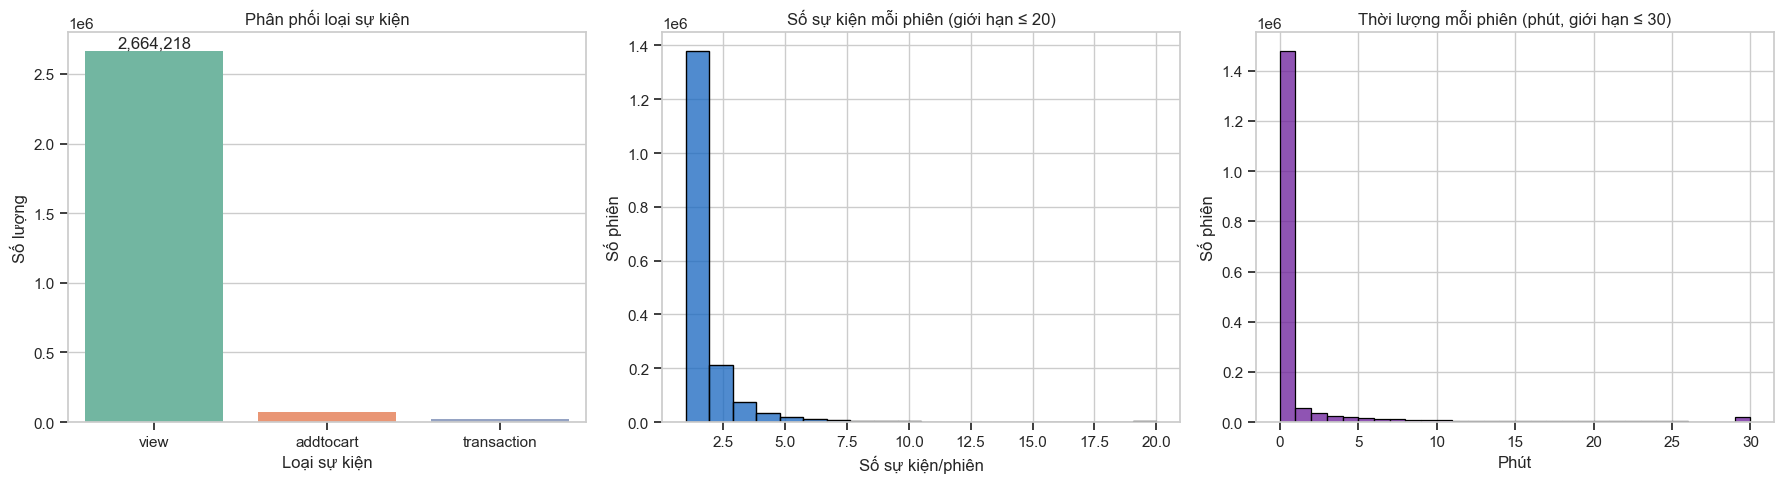

In [32]:
session_sizes = events.groupby('session_id').size()
session_duration = (events.groupby('session_id')['timestamp'].max() - events.groupby('session_id')['timestamp'].min()) / 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = events['event'].value_counts().index
sns.countplot(data=events, x='event', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Phân phối loại sự kiện')
axes[0].set_xlabel('Loại sự kiện')
axes[0].set_ylabel('Số lượng')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}')

sns.histplot(session_sizes.clip(upper=20), bins=20, color=COLORS['primary'], ax=axes[1])
axes[1].set_title('Số sự kiện mỗi phiên (giới hạn ≤ 20)')
axes[1].set_xlabel('Số sự kiện/phiên')
axes[1].set_ylabel('Số phiên')

sns.histplot((session_duration / 60).clip(upper=30), bins=30, color=COLORS['secondary'], ax=axes[2])
axes[2].set_title('Thời lượng mỗi phiên (phút, giới hạn ≤ 30)')
axes[2].set_xlabel('Phút')
axes[2].set_ylabel('Số phiên')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_session_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Xây dựng session behavior profile

Mỗi dòng của bảng profile tương ứng với một `session_id`. `visitorid` chỉ còn là metadata để truy vết người dùng.

In [33]:
print('Đang xây dựng session behavior profile...')
session_events = events.copy()
session_groups = session_events.groupby('session_id', sort=False)

session_profile = pd.DataFrame(index=session_groups.size().index)
session_profile.index.name = 'session_id'
session_profile['visitorid'] = session_groups['visitorid'].first().astype('int64')
session_profile['session_number'] = session_groups['session_number'].first().astype('int32')
session_profile['session_start'] = session_groups['datetime'].min()
session_profile['session_end'] = session_groups['datetime'].max()
session_profile['session_start_hour'] = session_profile['session_start'].dt.hour
session_profile['session_dayofweek'] = session_profile['session_start'].dt.dayofweek
session_profile['total_events'] = session_groups.size().astype('int32')
session_profile['unique_items'] = session_groups['itemid'].nunique().astype('int32')
session_profile['active_hours'] = session_groups['hour'].nunique().astype('int16')
session_profile['session_duration_sec'] = ((session_groups['timestamp'].max() - session_groups['timestamp'].min()) / 1000).astype('float32')

event_counts = session_events.groupby(['session_id', 'event']).size().unstack(fill_value=0)
event_counts.columns = [f'n_{column}' for column in event_counts.columns]
for column in ['n_view', 'n_addtocart', 'n_transaction']:
    if column not in event_counts.columns:
        event_counts[column] = 0
session_profile = session_profile.join(event_counts[['n_view', 'n_addtocart', 'n_transaction']].astype('int32'))
session_profile['unique_event_types'] = (session_profile[['n_view', 'n_addtocart', 'n_transaction']] > 0).sum(axis=1).astype('int8')

event_probabilities = event_counts[['n_view', 'n_addtocart', 'n_transaction']].div(session_profile['total_events'].clip(lower=1), axis=0)
session_profile['event_type_entropy'] = (-(event_probabilities.replace(0, np.nan) * np.log2(event_probabilities.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

hour_counts = session_events.groupby(['session_id', 'hour']).size().unstack(fill_value=0)
hour_probabilities = hour_counts.div(hour_counts.sum(axis=1).clip(lower=1), axis=0)
session_profile['hour_entropy'] = (-(hour_probabilities.replace(0, np.nan) * np.log2(hour_probabilities.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

events_with_interval = session_events.dropna(subset=['time_diff_session_sec'])
interval_stats = events_with_interval.groupby('session_id')['time_diff_session_sec'].agg(
    min_interval_sec='min',
    mean_interval_sec='mean',
    median_interval_sec='median',
    std_interval_sec='std',
    max_interval_sec='max',
)
session_profile = session_profile.join(interval_stats).fillna({
    'min_interval_sec': 0,
    'mean_interval_sec': 0,
    'median_interval_sec': 0,
    'std_interval_sec': 0,
    'max_interval_sec': 0,
})
interval_columns = ['min_interval_sec', 'mean_interval_sec', 'median_interval_sec', 'std_interval_sec', 'max_interval_sec']
session_profile[interval_columns] = session_profile[interval_columns].astype('float32')

session_profile['rapid_fire_count'] = events_with_interval[events_with_interval['time_diff_session_sec'] < 1].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')
session_profile['night_events'] = session_events[session_events['hour'].between(0, 5)].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')
session_profile['peak_events'] = session_events[session_events['hour'].between(9, 21)].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')
session_profile['weekend_events'] = session_events[session_events['dayofweek'].isin([5, 6])].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')

view_events = session_events[session_events['event'] == 'view']
if len(view_events) > 0:
    max_same_item_view = view_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    session_profile['max_same_item_view'] = max_same_item_view.reindex(session_profile.index, fill_value=0).astype('int16')
else:
    session_profile['max_same_item_view'] = 0

addtocart_events = session_events[session_events['event'] == 'addtocart']
if len(addtocart_events) > 0:
    max_same_item_addtocart = addtocart_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    session_profile['max_same_item_atc'] = max_same_item_addtocart.reindex(session_profile.index, fill_value=0).astype('int16')
else:
    session_profile['max_same_item_atc'] = 0

session_profile['duration_min'] = (session_profile['session_duration_sec'] / 60).clip(lower=1).astype('float32')
session_profile['events_per_minute'] = (session_profile['total_events'] / session_profile['duration_min']).astype('float32')
session_profile['view_rate'] = (session_profile['n_view'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['atc_rate'] = (session_profile['n_addtocart'] / session_profile['n_view'].clip(lower=1)).astype('float32')
session_profile['buy_rate'] = (session_profile['n_transaction'] / session_profile['n_view'].clip(lower=1)).astype('float32')
session_profile['night_ratio'] = (session_profile['night_events'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['peak_ratio'] = (session_profile['peak_events'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['weekend_ratio'] = (session_profile['weekend_events'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['rapid_ratio'] = (session_profile['rapid_fire_count'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['items_per_event'] = (session_profile['unique_items'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['view_to_cart_ratio'] = (session_profile['n_view'] / session_profile['n_addtocart'].clip(lower=1)).astype('float32')
session_profile['cart_to_transaction_ratio'] = (session_profile['n_addtocart'] / session_profile['n_transaction'].clip(lower=1)).astype('float32')

session_profile['unique_categories'] = 0
session_profile['unique_parent_categories'] = 0
try:
    item_properties_part1 = pd.read_csv('./data/item_properties_part1.csv', usecols=['itemid', 'property', 'value'])
    item_properties_part2 = pd.read_csv('./data/item_properties_part2.csv', usecols=['itemid', 'property', 'value'])
    item_categories = pd.concat([item_properties_part1, item_properties_part2], ignore_index=True)
    item_categories = item_categories[item_categories['property'].astype(str) == 'categoryid'][['itemid', 'value']]
    item_categories['categoryid'] = pd.to_numeric(item_categories['value'], errors='coerce')
    item_categories = item_categories.dropna(subset=['categoryid']).drop_duplicates('itemid')
    item_categories['categoryid'] = item_categories['categoryid'].astype('int64')

    category_tree = pd.read_csv('./data/category_tree.csv')
    category_parent = category_tree[['categoryid', 'parentid']].drop_duplicates('categoryid')
    item_categories = item_categories.merge(category_parent, on='categoryid', how='left')

    session_items = session_events[['session_id', 'itemid']].drop_duplicates()
    session_items = session_items.merge(item_categories[['itemid', 'categoryid', 'parentid']], on='itemid', how='left')
    session_profile['unique_categories'] = session_items.groupby('session_id')['categoryid'].nunique().reindex(session_profile.index, fill_value=0).astype('int16')
    session_profile['unique_parent_categories'] = session_items.groupby('session_id')['parentid'].nunique().reindex(session_profile.index, fill_value=0).astype('int16')
    print('Đã bổ sung đặc trưng danh mục từ item_properties và category_tree')
except Exception as category_error:
    print(f'Bỏ qua đặc trưng danh mục vì không nạp được item properties: {category_error}')

print(f'Kích thước session profile: {session_profile.shape}')
print(f'session_id là duy nhất: {session_profile.index.is_unique}')
display(session_profile.head())

Đang xây dựng session behavior profile...
Đã bổ sung đặc trưng danh mục từ item_properties và category_tree
Kích thước session profile: (1761675, 41)
session_id là duy nhất: True


,visitorid,session_number,session_start,session_end,session_start_hour,session_dayofweek,total_events,unique_items,active_hours,session_duration_sec,...,buy_rate,night_ratio,peak_ratio,weekend_ratio,rapid_ratio,items_per_event,view_to_cart_ratio,cart_to_transaction_ratio,unique_categories,unique_parent_categories
session_id,,,,,,,,,,,,,,,,,,,,,
0_S1,0,1,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,20,4,3,3,1,327.735992,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,3,2
1_S1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,17,3,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1,1
2_S1,2,1,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,17,4,8,4,2,1753.277954,...,0.0,0.0,1.0,0.0,0.0,0.5,8.0,0.0,2,1
3_S1,3,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,7,5,1,1,1,0.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,1
4_S1,4,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,21,1,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0,0


In [34]:
summary_cols = [
    'total_events', 'unique_items', 'unique_categories', 'unique_parent_categories',
    'session_duration_sec', 'events_per_minute', 'n_view', 'n_addtocart', 'n_transaction',
    'rapid_fire_count', 'rapid_ratio', 'night_ratio', 'max_same_item_view', 'max_same_item_atc',
    'event_type_entropy', 'hour_entropy',
]
profile_summary = session_profile[summary_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
print('Thống kê các đặc trưng session chính:')
display(profile_summary)

Thống kê các đặc trưng session chính:


,count,mean,std,min,50%,75%,90%,95%,99%,max
total_events,1761675.0,1.564216,2.599172,1.000000,1.0,1.0,2.000000,4.00000,9.000000,417.000000
unique_items,1761675.0,1.332739,1.784379,1.000000,1.0,1.0,2.000000,3.00000,6.000000,389.000000
unique_categories,1761675.0,0.964344,0.892530,0.000000,1.0,1.0,1.000000,1.00000,3.000000,114.000000
unique_parent_categories,1761675.0,0.942344,0.755826,0.000000,1.0,1.0,1.000000,1.00000,2.000000,79.000000
session_duration_sec,1761675.0,105.243446,499.529755,0.000000,0.0,0.0,213.162402,624.14751,1792.538149,43704.246094
events_per_minute,1761675.0,1.039757,0.440438,0.048184,1.0,1.0,1.116754,2.00000,3.000000,29.099926
n_view,1761675.0,1.512321,2.352375,0.000000,1.0,1.0,2.000000,4.00000,8.000000,417.000000
n_addtocart,1761675.0,0.039148,0.397012,0.000000,0.0,0.0,0.000000,0.00000,1.000000,114.000000
n_transaction,1761675.0,0.012748,0.207124,0.000000,0.0,0.0,0.000000,0.00000,0.000000,59.000000
rapid_fire_count,1761675.0,0.009295,0.181702,0.000000,0.0,0.0,0.000000,0.00000,0.000000,66.000000


## 4. Business rules và multi-label anomaly tagging theo session

Các luật gắn nhãn hành vi đáng nghi ở cấp session. Một session có thể mang nhiều anomaly type cùng lúc.

In [35]:
THRESHOLDS = {
    'BR01_min_events_bot': 12,
    'BR01_min_events_per_minute': 8,
    'BR01_min_events_for_speed': 5,
    'BR03_min_views_for_click_fraud': 6,
    'BR04_rapid_fire_count': 1,
    'BR04_rapid_fire_ratio': 0.20,
    'BR04_min_events_for_rapid': 3,
    'BR05_night_ratio': 0.75,
    'BR05_min_events_for_night': 4,
    'BR06_max_same_item_atc': 1,
    'BR07_min_unique_items_session_bomb': 12,
    'BR09_min_transactions_burst': 3,
    'BR10_min_addtocart_abandonment': 10,
    'BR11_max_same_item_view': 20,
    'BR12_min_unique_categories': 20,
}

sessions = session_profile.copy()

sessions['flag_BR01_bot_scraper'] = (
    (sessions['total_events'] >= THRESHOLDS['BR01_min_events_bot'])
    | (
        (sessions['events_per_minute'] >= THRESHOLDS['BR01_min_events_per_minute'])
        & (sessions['total_events'] >= THRESHOLDS['BR01_min_events_for_speed'])
    )
).astype(int)

sessions['flag_BR02_ghost_buyer'] = (
    (sessions['n_transaction'] > 0) & (sessions['n_addtocart'] == 0)
).astype(int)

sessions['flag_BR03_click_fraud'] = (
    (sessions['n_view'] >= THRESHOLDS['BR03_min_views_for_click_fraud'])
    & (sessions['n_addtocart'] == 0)
    & (sessions['n_transaction'] == 0)
).astype(int)

sessions['flag_BR04_rapid_fire'] = (
    (
        (sessions['rapid_fire_count'] >= THRESHOLDS['BR04_rapid_fire_count'])
        | (sessions['rapid_ratio'] >= THRESHOLDS['BR04_rapid_fire_ratio'])
    )
    & (sessions['total_events'] >= THRESHOLDS['BR04_min_events_for_rapid'])
).astype(int)

sessions['flag_BR05_night_crawler'] = (
    (sessions['night_ratio'] >= THRESHOLDS['BR05_night_ratio'])
    & (sessions['total_events'] >= THRESHOLDS['BR05_min_events_for_night'])
).astype(int)

sessions['flag_BR06_item_hoarding'] = (
    sessions['max_same_item_atc'] > THRESHOLDS['BR06_max_same_item_atc']
).astype(int)

sessions['flag_BR07_session_bomb'] = (
    sessions['unique_items'] >= THRESHOLDS['BR07_min_unique_items_session_bomb']
).astype(int)

interaction_event = session_events['event'].isin(['view', 'addtocart']).astype('int8')
prior_item_interactions = interaction_event.groupby([session_events['session_id'], session_events['itemid']]).cumsum()
sequence_violation_sessions = session_events.loc[
    (session_events['event'] == 'transaction') & (prior_item_interactions == 0),
    'session_id',
].unique()
sessions['flag_BR08_sequence_violation'] = sessions.index.isin(sequence_violation_sessions).astype(int)

sessions['flag_BR09_transaction_burst'] = (
    sessions['n_transaction'] >= THRESHOLDS['BR09_min_transactions_burst']
).astype(int)

sessions['flag_BR10_cart_abandonment'] = (
    (sessions['n_addtocart'] >= THRESHOLDS['BR10_min_addtocart_abandonment'])
    & (sessions['n_transaction'] == 0)
).astype(int)

sessions['flag_BR11_repeated_view_spam'] = (
    sessions['max_same_item_view'] >= THRESHOLDS['BR11_max_same_item_view']
).astype(int)

sessions['flag_BR12_category_scanning'] = (
    sessions['unique_categories'] >= THRESHOLDS['BR12_min_unique_categories']
).astype(int)

anomaly_type_map = {
    'flag_BR01_bot_scraper': 'Bot scraper',
    'flag_BR02_ghost_buyer': 'Ghost buyer',
    'flag_BR03_click_fraud': 'Click fraud',
    'flag_BR04_rapid_fire': 'Rapid-fire',
    'flag_BR05_night_crawler': 'Night crawler',
    'flag_BR06_item_hoarding': 'Item hoarding',
    'flag_BR07_session_bomb': 'Session bomb',
    'flag_BR08_sequence_violation': 'Sequence violation',
    'flag_BR09_transaction_burst': 'Transaction burst',
    'flag_BR10_cart_abandonment': 'Cart abandonment',
    'flag_BR11_repeated_view_spam': 'Repeated view spam',
    'flag_BR12_category_scanning': 'Category scanning',
}

flag_cols = list(anomaly_type_map.keys())
sessions['total_flags'] = sessions[flag_cols].sum(axis=1)
sessions['is_anomaly_rule'] = (sessions['total_flags'] > 0).astype(int)
sessions['is_anomaly'] = sessions['is_anomaly_rule']

flag_matrix = sessions[flag_cols].to_numpy(dtype=bool)
anomaly_type_labels = np.array(list(anomaly_type_map.values()), dtype=object)
sessions['anomaly_type_count'] = flag_matrix.sum(axis=1).astype(int)
sessions['anomaly_types'] = [
    ', '.join(anomaly_type_labels[row_flags].tolist()) if row_flags.any() else 'Normal'
    for row_flags in flag_matrix
]

if not (sessions['anomaly_type_count'] == sessions['total_flags']).all():
    raise ValueError('anomaly_type_count phải bằng total_flags')
if not (sessions.loc[sessions['is_anomaly'] == 0, 'anomaly_types'] == 'Normal').all():
    raise ValueError('Session bình thường phải có anomaly_types = Normal')

rule_summary = (
    sessions[flag_cols]
    .sum()
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'flag'})
)
rule_summary['anomaly_type'] = rule_summary['flag'].map(anomaly_type_map)
rule_summary['percent_sessions'] = rule_summary['count'] / len(sessions) * 100
rule_summary = rule_summary[['flag', 'anomaly_type', 'count', 'percent_sessions']].sort_values('count', ascending=False)
anomaly_type_breakdown = rule_summary[['anomaly_type', 'count', 'percent_sessions']].copy()

session_anomaly_tags = sessions[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

print('Ngưỡng luật nghiệp vụ ở cấp session:')
for threshold_name, threshold_value in THRESHOLDS.items():
    print(f'- {threshold_name}: {threshold_value}')

print(f'\nSố session bất thường theo luật: {sessions["is_anomaly_rule"].sum():,} / {len(sessions):,} '
      f'({sessions["is_anomaly_rule"].mean() * 100:.2f}%)')
display(rule_summary)
print('\nVí dụ multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))

Ngưỡng luật nghiệp vụ ở cấp session:
- BR01_min_events_bot: 12
- BR01_min_events_per_minute: 8
- BR01_min_events_for_speed: 5
- BR03_min_views_for_click_fraud: 6
- BR04_rapid_fire_count: 1
- BR04_rapid_fire_ratio: 0.2
- BR04_min_events_for_rapid: 3
- BR05_night_ratio: 0.75
- BR05_min_events_for_night: 4
- BR06_max_same_item_atc: 1
- BR07_min_unique_items_session_bomb: 12
- BR09_min_transactions_burst: 3
- BR10_min_addtocart_abandonment: 10
- BR11_max_same_item_view: 20
- BR12_min_unique_categories: 20

Số session bất thường theo luật: 61,849 / 1,761,675 (3.51%)


,flag,anomaly_type,count,percent_sessions
2,flag_BR03_click_fraud,Click fraud,31213,1.771780
4,flag_BR05_night_crawler,Night crawler,30130,1.710304
0,flag_BR01_bot_scraper,Bot scraper,10884,0.617821
3,flag_BR04_rapid_fire,Rapid-fire,8052,0.457065
6,flag_BR07_session_bomb,Session bomb,5112,0.290178
5,flag_BR06_item_hoarding,Item hoarding,3212,0.182326
1,flag_BR02_ghost_buyer,Ghost buyer,2365,0.134247
7,flag_BR08_sequence_violation,Sequence violation,1573,0.089290
8,flag_BR09_transaction_burst,Transaction burst,1558,0.088439
11,flag_BR12_category_scanning,Category scanning,628,0.035648



Ví dụ multi-label anomaly tagging theo session:


,session_id,visitorid,session_number,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
2,2_S1,2,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
63,51_S1,51,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
66,54_S1,54,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
140,97_S1,97,1,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
218,162_S1,162,1,1,Night crawler,1,1,0,0,0,0,1,0,0,0,0,0,0,0
234,172_S2,172,2,1,"Bot scraper, Click fraud, Night crawler, Sessi...",4,4,1,0,1,0,1,0,1,0,0,0,0,0
235,172_S3,172,3,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
236,172_S4,172,4,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,4,1,0,0,1,1,1,0,0,0,0,0,0
293,224_S1,224,1,1,"Bot scraper, Click fraud, Night crawler",3,3,1,0,1,0,1,0,0,0,0,0,0,0
336,264_S1,264,1,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0,0,0,0,0


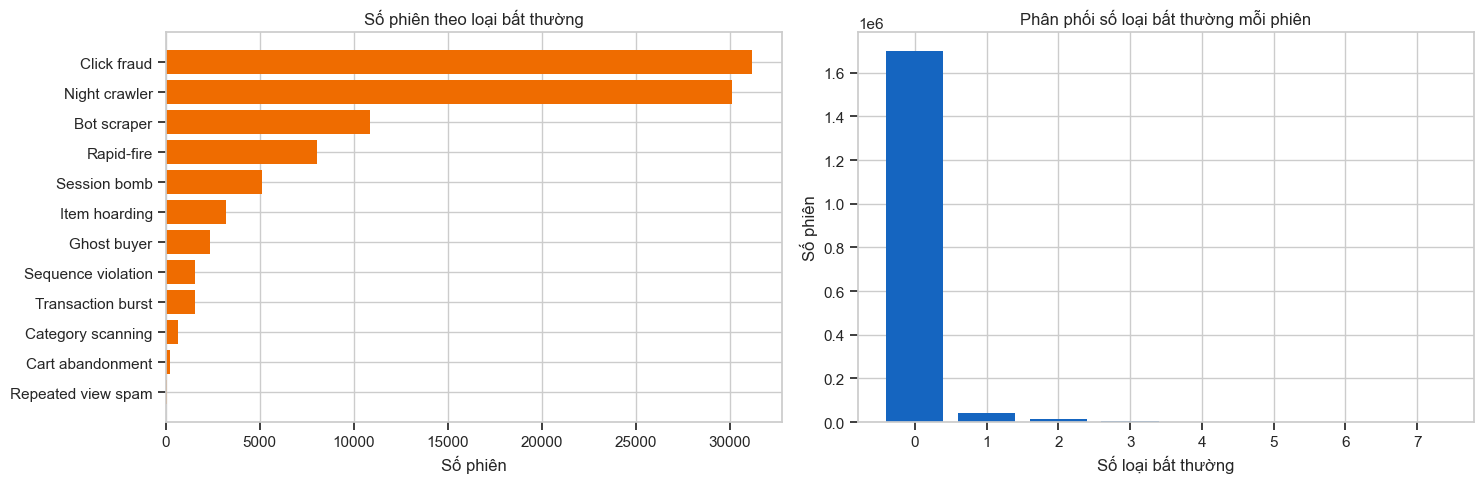

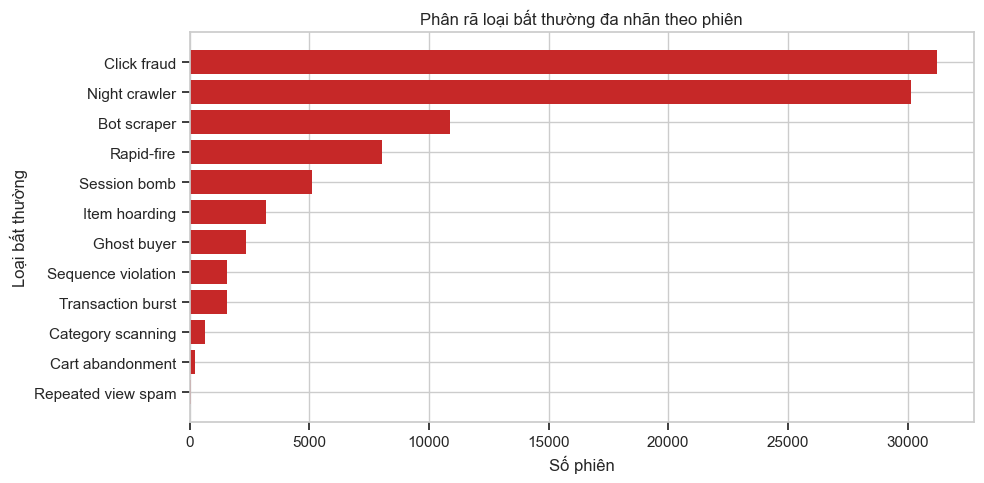

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_rules = rule_summary.sort_values('count', ascending=True)
axes[0].barh(plot_rules['anomaly_type'], plot_rules['count'], color=COLORS['warning'])
axes[0].set_title('Số phiên theo loại bất thường')
axes[0].set_xlabel('Số phiên')

flag_distribution = sessions['total_flags'].value_counts().sort_index()
axes[1].bar(flag_distribution.index.astype(str), flag_distribution.values, color=COLORS['primary'])
axes[1].set_title('Phân phối số loại bất thường mỗi phiên')
axes[1].set_xlabel('Số loại bất thường')
axes[1].set_ylabel('Số phiên')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_rule_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_type_breakdown = anomaly_type_breakdown.sort_values('count', ascending=True)
ax.barh(plot_type_breakdown['anomaly_type'], plot_type_breakdown['count'], color=COLORS['anomaly'])
ax.set_title('Phân rã loại bất thường đa nhãn theo phiên')
ax.set_xlabel('Số phiên')
ax.set_ylabel('Loại bất thường')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_anomaly_type_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Kiểm tra rò rỉ nhãn theo luật nghiệp vụ

`full_feature_cols` chứa các feature tạo luật để minh họa rule-mimic. `safe_feature_cols` loại feature trực tiếp tạo nhãn và dùng cho bảng metric chính.

Kiểm tra rò rỉ nhãn: tập đặc trưng an toàn đã loại bỏ các đặc trưng trực tiếp tạo ra luật.


,rule,business_condition,rule_input_features,leaked_inputs_in_full_features,inputs_remaining_in_safe_features,n_leaked_inputs
0,BR01_bot_scraper,total_events >= 12 or events_per_minute >= 8 w...,"[total_events, events_per_minute]","[total_events, events_per_minute]",[],2
1,BR02_ghost_buyer,n_transaction > 0 and n_addtocart == 0,"[n_transaction, n_addtocart]","[n_transaction, n_addtocart]",[],2
2,BR03_click_fraud,n_view >= 6 and n_addtocart == 0 and n_transac...,"[n_view, n_addtocart, n_transaction]","[n_view, n_addtocart, n_transaction]",[],3
3,BR04_rapid_fire,rapid_fire_count >= 1 or rapid_ratio >= 0.20 w...,"[rapid_fire_count, rapid_ratio, total_events]","[rapid_fire_count, rapid_ratio, total_events]",[],3
4,BR05_night_crawler,night_ratio >= 0.75 and total_events >= 4,"[night_ratio, night_events, total_events]","[night_ratio, night_events, total_events]",[],3
5,BR06_item_hoarding,max_same_item_atc > 1,[max_same_item_atc],[max_same_item_atc],[],1
6,BR07_session_bomb,unique_items >= 12,[unique_items],[unique_items],[],1
7,BR08_sequence_violation,transaction before prior view/addtocart on sam...,[raw_event_sequence],[],[],0
8,BR09_transaction_burst,n_transaction >= 3,[n_transaction],[n_transaction],[],1
9,BR10_cart_abandonment,n_addtocart >= 10 and n_transaction == 0,"[n_addtocart, n_transaction]","[n_addtocart, n_transaction]",[],2


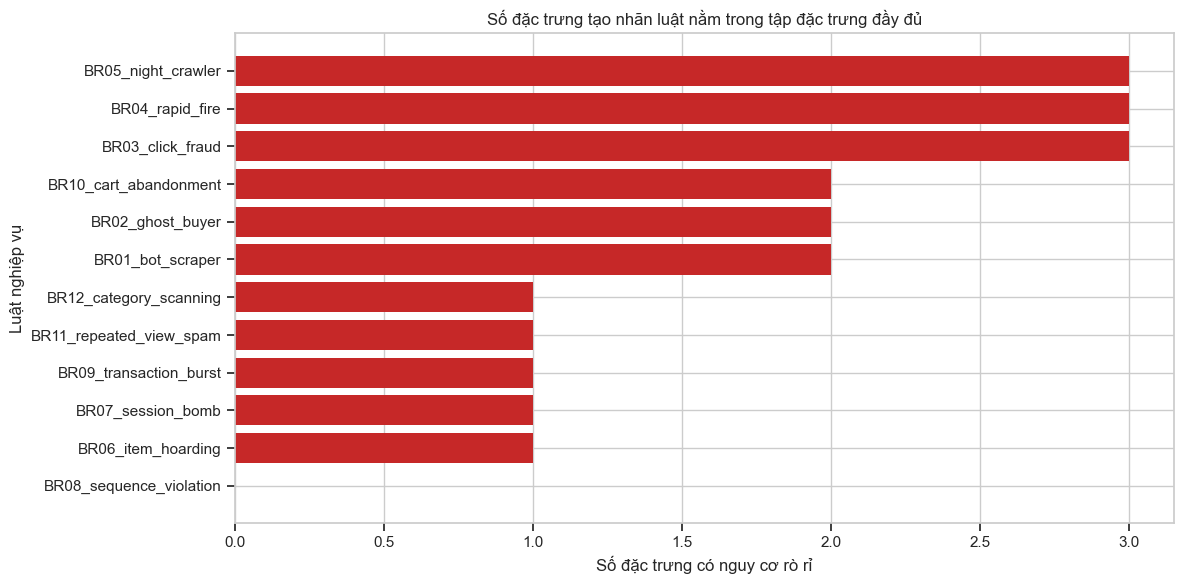

In [37]:
leakage_audit_df = pd.DataFrame([
    {'rule': 'BR01_bot_scraper', 'business_condition': 'total_events >= 12 or events_per_minute >= 8 with enough events', 'rule_input_features': ['total_events', 'events_per_minute']},
    {'rule': 'BR02_ghost_buyer', 'business_condition': 'n_transaction > 0 and n_addtocart == 0', 'rule_input_features': ['n_transaction', 'n_addtocart']},
    {'rule': 'BR03_click_fraud', 'business_condition': 'n_view >= 6 and n_addtocart == 0 and n_transaction == 0', 'rule_input_features': ['n_view', 'n_addtocart', 'n_transaction']},
    {'rule': 'BR04_rapid_fire', 'business_condition': 'rapid_fire_count >= 1 or rapid_ratio >= 0.20 with enough events', 'rule_input_features': ['rapid_fire_count', 'rapid_ratio', 'total_events']},
    {'rule': 'BR05_night_crawler', 'business_condition': 'night_ratio >= 0.75 and total_events >= 4', 'rule_input_features': ['night_ratio', 'night_events', 'total_events']},
    {'rule': 'BR06_item_hoarding', 'business_condition': 'max_same_item_atc > 1', 'rule_input_features': ['max_same_item_atc']},
    {'rule': 'BR07_session_bomb', 'business_condition': 'unique_items >= 12', 'rule_input_features': ['unique_items']},
    {'rule': 'BR08_sequence_violation', 'business_condition': 'transaction before prior view/addtocart on same session-item timeline', 'rule_input_features': ['raw_event_sequence']},
    {'rule': 'BR09_transaction_burst', 'business_condition': 'n_transaction >= 3', 'rule_input_features': ['n_transaction']},
    {'rule': 'BR10_cart_abandonment', 'business_condition': 'n_addtocart >= 10 and n_transaction == 0', 'rule_input_features': ['n_addtocart', 'n_transaction']},
    {'rule': 'BR11_repeated_view_spam', 'business_condition': 'max_same_item_view >= 20', 'rule_input_features': ['max_same_item_view']},
    {'rule': 'BR12_category_scanning', 'business_condition': 'unique_categories >= 20', 'rule_input_features': ['unique_categories']},
])

full_feature_cols = [
    'total_events', 'unique_items', 'session_duration_sec', 'duration_min', 'events_per_minute',
    'n_view', 'n_addtocart', 'n_transaction', 'active_hours', 'unique_event_types',
    'event_type_entropy', 'hour_entropy', 'min_interval_sec', 'mean_interval_sec',
    'median_interval_sec', 'std_interval_sec', 'max_interval_sec', 'rapid_fire_count',
    'night_events', 'peak_events', 'weekend_events', 'view_rate', 'atc_rate', 'buy_rate',
    'night_ratio', 'peak_ratio', 'weekend_ratio', 'rapid_ratio', 'items_per_event',
    'view_to_cart_ratio', 'cart_to_transaction_ratio', 'max_same_item_view', 'max_same_item_atc',
    'unique_categories', 'unique_parent_categories', 'session_start_hour', 'session_dayofweek',
]

safe_feature_cols = [
    'session_duration_sec',
    'active_hours',
    'unique_event_types',
    'event_type_entropy',
    'hour_entropy',
    'mean_interval_sec',
    'median_interval_sec',
    'std_interval_sec',
    'max_interval_sec',
    'peak_events',
    'weekend_events',
    'peak_ratio',
    'weekend_ratio',
    'unique_parent_categories',
    'session_dayofweek',
]

leaky_feature_set = set(full_feature_cols).difference(safe_feature_cols)
leakage_audit_df['leaked_inputs_in_full_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in leaky_feature_set]
)
leakage_audit_df['inputs_remaining_in_safe_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in safe_feature_cols]
)
leakage_audit_df['n_leaked_inputs'] = leakage_audit_df['leaked_inputs_in_full_features'].str.len()

print('Kiểm tra rò rỉ nhãn: tập đặc trưng an toàn đã loại bỏ các đặc trưng trực tiếp tạo ra luật.')
display(leakage_audit_df)

if leakage_audit_df['inputs_remaining_in_safe_features'].str.len().sum() != 0:
    raise ValueError('safe_feature_cols vẫn chứa đặc trưng trực tiếp tạo nhãn luật')

fig, ax = plt.subplots(figsize=(12, 6))
plot_leakage = leakage_audit_df.sort_values('n_leaked_inputs', ascending=True)
ax.barh(plot_leakage['rule'], plot_leakage['n_leaked_inputs'], color=COLORS['anomaly'])
ax.set_title('Số đặc trưng tạo nhãn luật nằm trong tập đặc trưng đầy đủ')
ax.set_xlabel('Số đặc trưng có nguy cơ rò rỉ')
ax.set_ylabel('Luật nghiệp vụ')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_leakage_audit.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Chuẩn bị dữ liệu mô hình

Bảng metric chính dùng `safe_feature_cols`; bảng phụ `full_feature_cols` chỉ để chứng minh mô hình học lại luật khi có leakage.

Dữ liệu supervised được chia theo tỉ lệ **60% train - 20% validation - 20% test**. Validation dùng để chọn ngưỡng dự đoán/anomaly score, còn test dùng làm kết quả báo cáo cuối.


In [38]:
def build_clean_feature_matrix(source_dataframe, columns):
    feature_matrix = source_dataframe[columns].replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    if feature_matrix.isna().any().any():
        raise ValueError('Ma trận đặc trưng vẫn còn NaN sau khi xử lý')
    if not np.isfinite(feature_matrix.to_numpy()).all():
        raise ValueError('Ma trận đặc trưng vẫn còn inf sau khi xử lý')
    return feature_matrix

features_full = build_clean_feature_matrix(sessions, full_feature_cols)
features_safe = build_clean_feature_matrix(sessions, safe_feature_cols)
labels = sessions['is_anomaly_rule'].astype(int)

if labels.nunique() != 2:
    raise ValueError('Nhãn is_anomaly_rule phải có đủ 2 lớp')

all_indices = np.arange(len(labels))
if MAX_SUPERVISED_ROWS is not None and len(labels) > MAX_SUPERVISED_ROWS:
    supervised_indices, _ = train_test_split(
        all_indices,
        train_size=MAX_SUPERVISED_ROWS,
        random_state=RANDOM_STATE,
        stratify=labels,
    )
else:
    supervised_indices = all_indices

visitor_ids_all = sessions['visitorid'].to_numpy()
visitor_ids_supervised = visitor_ids_all[supervised_indices]
labels_supervised = labels.iloc[supervised_indices].to_numpy()

group_splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_validation_positions, test_positions = next(group_splitter_test.split(supervised_indices, labels_supervised, visitor_ids_supervised))
train_validation_indices = supervised_indices[train_validation_positions]
test_indices = supervised_indices[test_positions]

visitor_ids_train_validation = visitor_ids_all[train_validation_indices]
labels_train_validation = labels.iloc[train_validation_indices].to_numpy()
group_splitter_validation = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_positions, validation_positions = next(group_splitter_validation.split(train_validation_indices, labels_train_validation, visitor_ids_train_validation))
train_indices = train_validation_indices[train_positions]
validation_indices = train_validation_indices[validation_positions]

features_safe_train = features_safe.iloc[train_indices]
features_safe_validation = features_safe.iloc[validation_indices]
features_safe_test = features_safe.iloc[test_indices]
features_full_train = features_full.iloc[train_indices]
features_full_validation = features_full.iloc[validation_indices]
features_full_test = features_full.iloc[test_indices]
labels_train = labels.iloc[train_indices]
labels_validation = labels.iloc[validation_indices]
labels_test = labels.iloc[test_indices]

safe_feature_scaler = RobustScaler()
safe_feature_scaler.fit(features_safe_train)
features_safe_scaled = safe_feature_scaler.transform(features_safe).astype('float32')
features_safe_scaled_train = features_safe_scaled[train_indices]
features_safe_scaled_validation = features_safe_scaled[validation_indices]
features_safe_scaled_test = features_safe_scaled[test_indices]

full_feature_scaler = RobustScaler()
full_feature_scaler.fit(features_full_train)
features_full_scaled = full_feature_scaler.transform(features_full).astype('float32')

print(f'Toàn bộ session profile: {len(features_safe):,} dòng')
print(f'Mẫu supervised train/validation/test: {len(supervised_indices):,} dòng')
print(f'Train: {len(train_indices):,}; Validation: {len(validation_indices):,}; Test: {len(test_indices):,}')
print(f'Tỉ lệ anomaly trong toàn bộ session: {labels.mean() * 100:.2f}%')
print(f'Tỉ lệ anomaly trong train: {labels_train.mean() * 100:.2f}%')
print(f'Tỉ lệ anomaly trong validation: {labels_validation.mean() * 100:.2f}%')
print(f'Tỉ lệ anomaly trong test: {labels_test.mean() * 100:.2f}%')
print(f'Số safe features: {len(safe_feature_cols)}; Số full features: {len(full_feature_cols)}')

visitors_train = set(visitor_ids_all[train_indices])
visitors_validation = set(visitor_ids_all[validation_indices])
visitors_test = set(visitor_ids_all[test_indices])
overlap_train_validation = visitors_train & visitors_validation
overlap_train_test = visitors_train & visitors_test
overlap_validation_test = visitors_validation & visitors_test
print(f'Visitor train/validation/test: {len(visitors_train):,} / {len(visitors_validation):,} / {len(visitors_test):,}')
print(f'Trùng visitor train-validation: {len(overlap_train_validation)}; train-test: {len(overlap_train_test)}; validation-test: {len(overlap_validation_test)}')
assert not (overlap_train_validation or overlap_train_test or overlap_validation_test), 'Vẫn còn visitor bị rò rỉ giữa các tập!'
print('OK: không có visitor nào bị rò rỉ giữa train/validation/test (tách nhóm theo visitorid).')

Toàn bộ session profile: 1,761,675 dòng
Mẫu supervised train/validation/test: 1,761,675 dòng
Train: 1,056,863; Validation: 352,486; Test: 352,326
Tỉ lệ anomaly trong toàn bộ session: 3.51%
Tỉ lệ anomaly trong train: 3.51%
Tỉ lệ anomaly trong validation: 3.48%
Tỉ lệ anomaly trong test: 3.55%
Số safe features: 15; Số full features: 37
Visitor train/validation/test: 844,548 / 281,516 / 281,516
Trùng visitor train-validation: 0; train-test: 0; validation-test: 0
OK: không có visitor nào bị rò rỉ giữa train/validation/test (tách nhóm theo visitorid).


In [39]:
BASELINE_EVALUATION = 'Baseline so với nhãn giả phiên'
MAIN_SUPERVISED_EVALUATION = 'Mô hình giám sát chính so với nhãn giả phiên'
RULE_MIMIC_EVALUATION = 'Rule-mimic / agreement with session business rules'
UNSUPERVISED_EVALUATION = 'Unsupervised overlap with session pseudo-label'
SANITY_CHECK_EVALUATION = 'Sanity check: shuffled labels should fail'

evaluation_records = []
confusion_prediction_sets = {}

def choose_best_threshold(true_labels, scores, label, metric='f1'):
    true_labels = np.asarray(true_labels).astype(int)
    scores = np.asarray(scores, dtype='float64')
    if len(scores) == 0 or len(np.unique(scores)) <= 1:
        print(f'{label}: điểm số không đủ biến thiên, dùng ngưỡng mặc định 0.5')
        return 0.5

    candidate_thresholds = np.unique(np.r_[0.5, np.quantile(scores, np.linspace(0.01, 0.99, 99))])
    best_threshold = 0.5
    best_value = -1.0
    best_precision = -1.0
    best_recall = -1.0

    for threshold in candidate_thresholds:
        predictions = (scores >= threshold).astype(int)
        if metric == 'recall':
            value = recall_score(true_labels, predictions, zero_division=0)
        elif metric == 'precision':
            value = precision_score(true_labels, predictions, zero_division=0)
        else:
            value = f1_score(true_labels, predictions, zero_division=0)
        precision = precision_score(true_labels, predictions, zero_division=0)
        recall = recall_score(true_labels, predictions, zero_division=0)

        if (
            value > best_value
            or (np.isclose(value, best_value) and precision > best_precision)
            or (np.isclose(value, best_value) and np.isclose(precision, best_precision) and recall > best_recall)
        ):
            best_threshold = float(threshold)
            best_value = float(value)
            best_precision = float(precision)
            best_recall = float(recall)

    print(
        f'{label}: chọn ngưỡng={best_threshold:.4f} trên validation '
        f'({metric}={best_value:.4f}, precision={best_precision:.4f}, recall={best_recall:.4f})'
    )
    return best_threshold

def record_evaluation(model_name, feature_set, evaluation_type, split,
                      true_labels, predictions, scores=None,
                      threshold=np.nan, store_confusion=True):
    true_labels = np.asarray(true_labels).astype(int)
    predictions = np.asarray(predictions).astype(int)

    record = {
        'model': model_name,
        'feature_set': feature_set,
        'evaluation_type': evaluation_type,
        'split': split,
        'threshold': threshold,
        'accuracy': accuracy_score(true_labels, predictions),
        'precision': precision_score(true_labels, predictions, zero_division=0),
        'recall': recall_score(true_labels, predictions, zero_division=0),
        'f1_score': f1_score(true_labels, predictions, zero_division=0),
        'roc_auc': np.nan,
        'pr_auc': np.nan,
        'support_anomaly': int(true_labels.sum()),
        'predicted_anomaly': int(predictions.sum()),
    }

    if scores is not None and len(np.unique(true_labels)) == 2:
        try:
            record['roc_auc'] = roc_auc_score(true_labels, scores)
        except ValueError:
            record['roc_auc'] = np.nan
        try:
            record['pr_auc'] = average_precision_score(true_labels, scores)
        except ValueError:
            record['pr_auc'] = np.nan

    evaluation_records.append(record)
    confusion_key = f'{model_name} ({feature_set})'
    if store_confusion:
        confusion_prediction_sets[confusion_key] = {
            'y_true': true_labels,
            'y_pred': predictions,
            'evaluation_type': evaluation_type,
            'split': split,
        }

    print()
    print(f'{model_name} - {feature_set} - {evaluation_type} - {split}')
    print(classification_report(true_labels, predictions, target_names=['Normal', 'Anomaly'], zero_division=0))

def train_and_evaluate_supervised_model(model, model_name,
                                        features_train, labels_train,
                                        features_validation, labels_validation,
                                        features_test, labels_test,
                                        features_all,
                                        feature_set='safe_features',
                                        evaluation_type=MAIN_SUPERVISED_EVALUATION,
                                        store_test_confusion=True):
    model.fit(features_train, labels_train)

    validation_scores = model.predict_proba(features_validation)[:, 1]
    threshold = choose_best_threshold(labels_validation, validation_scores, f'{model_name} ({feature_set})')

    validation_predictions = (validation_scores >= threshold).astype(int)
    record_evaluation(model_name, feature_set, evaluation_type, 'validation',
                      labels_validation, validation_predictions, validation_scores,
                      threshold=threshold, store_confusion=False)

    test_scores = model.predict_proba(features_test)[:, 1]
    test_predictions = (test_scores >= threshold).astype(int)
    record_evaluation(model_name, feature_set, evaluation_type, 'test',
                      labels_test, test_predictions, test_scores,
                      threshold=threshold, store_confusion=store_test_confusion)

    scores_all_sessions = model.predict_proba(features_all)[:, 1]
    predictions_all_sessions = (scores_all_sessions >= threshold).astype(int)
    return model, threshold, scores_all_sessions, predictions_all_sessions

## 7. Baseline và mô hình supervised trên safe feature set

Các mô hình supervised học trên `train`, chọn threshold bằng `validation`, và chỉ dùng `test` để báo cáo kết quả cuối.


In [40]:
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(features_safe_train, labels_train)

dummy_validation_predictions = dummy_model.predict(features_safe_validation)
dummy_validation_scores = dummy_model.predict_proba(features_safe_validation)[:, 1]
record_evaluation(
    'Dummy baseline',
    'safe_features',
    BASELINE_EVALUATION,
    'validation',
    labels_validation,
    dummy_validation_predictions,
    dummy_validation_scores,
    threshold=0.5,
    store_confusion=False,
)

dummy_test_predictions = dummy_model.predict(features_safe_test)
dummy_test_scores = dummy_model.predict_proba(features_safe_test)[:, 1]
record_evaluation(
    'Dummy baseline',
    'safe_features',
    BASELINE_EVALUATION,
    'test',
    labels_test,
    dummy_test_predictions,
    dummy_test_scores,
    threshold=0.5,
    store_confusion=False,
)


Dummy baseline - safe_features - Baseline so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.96    340215
     Anomaly       0.03      0.04      0.03     12271

    accuracy                           0.93    352486
   macro avg       0.50      0.50      0.50    352486
weighted avg       0.93      0.93      0.93    352486


Dummy baseline - safe_features - Baseline so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96    339835
     Anomaly       0.03      0.03      0.03     12491

    accuracy                           0.93    352326
   macro avg       0.50      0.50      0.50    352326
weighted avg       0.93      0.93      0.93    352326



<a id="section-xgboost"></a>

### Đình Tuấn - XGBoost

In [41]:
def make_xgboost_model(n_estimators=120, scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=n_estimators,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

negative_count = int((labels_train == 0).sum())
positive_count = int((labels_train == 1).sum())
scale_pos_weight = negative_count / max(positive_count, 1)

xgboost_model = make_xgboost_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
(
    xgboost_model,
    xgboost_threshold,
    xgboost_scores_all,
    xgboost_predictions_all,
) = train_and_evaluate_supervised_model(
    model=xgboost_model,
    model_name='XGBoost',
    features_train=features_safe_train,
    labels_train=labels_train,
    features_validation=features_safe_validation,
    labels_validation=labels_validation,
    features_test=features_safe_test,
    labels_test=labels_test,
    features_all=features_safe,
)

sessions['xgboost_score'] = xgboost_scores_all
sessions['xgboost_pred'] = xgboost_predictions_all

XGBoost (safe_features): chọn ngưỡng=0.8845 trên validation (f1=0.8609, precision=0.8051, recall=0.9251)

XGBoost - safe_features - Mô hình giám sát chính so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    340215
     Anomaly       0.81      0.93      0.86     12271

    accuracy                           0.99    352486
   macro avg       0.90      0.96      0.93    352486
weighted avg       0.99      0.99      0.99    352486


XGBoost - safe_features - Mô hình giám sát chính so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    339835
     Anomaly       0.81      0.93      0.86     12491

    accuracy                           0.99    352326
   macro avg       0.90      0.96      0.93    352326
weighted avg       0.99      0.99      0.99    352326



### Lê Văn Anh - Decision Tree

Decision Tree (safe_features): chọn ngưỡng=0.9836 trên validation (f1=0.7453, precision=0.7904, recall=0.7051)

Decision Tree - safe_features - Mô hình giám sát chính so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    340215
     Anomaly       0.79      0.71      0.75     12271

    accuracy                           0.98    352486
   macro avg       0.89      0.85      0.87    352486
weighted avg       0.98      0.98      0.98    352486


Decision Tree - safe_features - Mô hình giám sát chính so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    339835
     Anomaly       0.79      0.71      0.75     12491

    accuracy                           0.98    352326
   macro avg       0.89      0.85      0.87    352326
weighted avg       0.98      0.98      0.98    352326



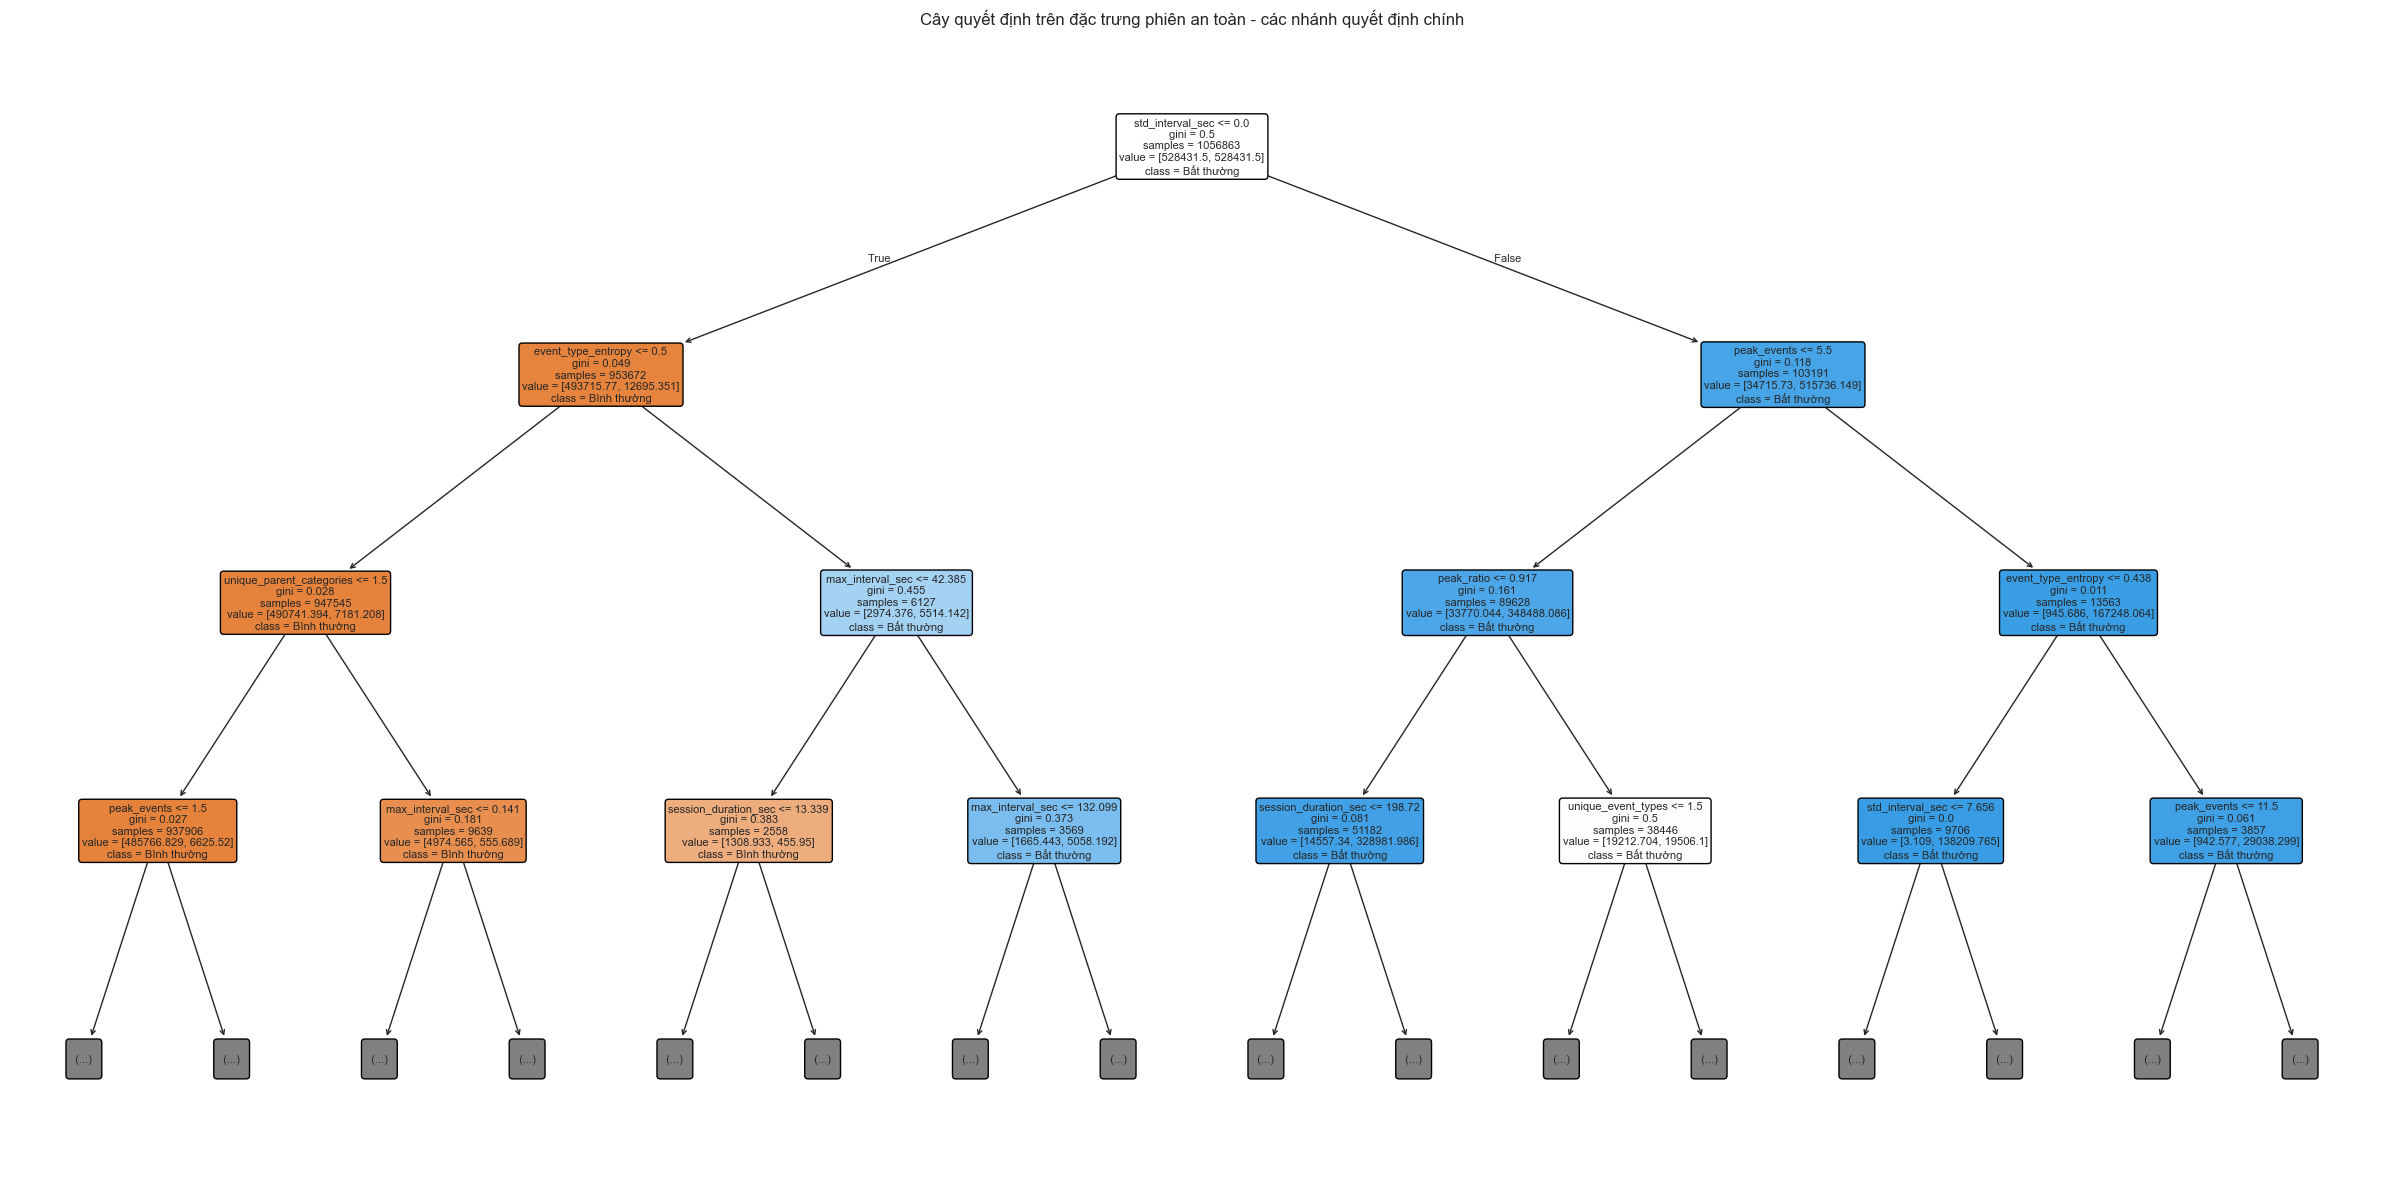

In [42]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
(
    decision_tree_model,
    decision_tree_threshold,
    decision_tree_scores_all,
    decision_tree_predictions_all,
) = train_and_evaluate_supervised_model(
    model=decision_tree_model,
    model_name='Decision Tree',
    features_train=features_safe_train,
    labels_train=labels_train,
    features_validation=features_safe_validation,
    labels_validation=labels_validation,
    features_test=features_safe_test,
    labels_test=labels_test,
    features_all=features_safe,
)

sessions['decision_tree_score'] = decision_tree_scores_all
sessions['decision_tree_pred'] = decision_tree_predictions_all

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    decision_tree_model,
    feature_names=safe_feature_cols,
    class_names=['Bình thường', 'Bất thường'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title('Cây quyết định trên đặc trưng phiên an toàn - các nhánh quyết định chính')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_decision_tree.png', dpi=160, bbox_inches='tight')
plt.show()

<a id="section-random-forest"></a>

### Tuấn Anh - Random Forest

In [43]:
random_forest_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
(
    random_forest_model,
    random_forest_threshold,
    random_forest_scores_all,
    random_forest_predictions_all,
) = train_and_evaluate_supervised_model(
    model=random_forest_model,
    model_name='Random Forest',
    features_train=features_safe_train,
    labels_train=labels_train,
    features_validation=features_safe_validation,
    labels_validation=labels_validation,
    features_test=features_safe_test,
    labels_test=labels_test,
    features_all=features_safe,
)

sessions['random_forest_score'] = random_forest_scores_all
sessions['random_forest_pred'] = random_forest_predictions_all

Random Forest (safe_features): chọn ngưỡng=0.8601 trên validation (f1=0.8629, precision=0.8070, recall=0.9272)

Random Forest - safe_features - Mô hình giám sát chính so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    340215
     Anomaly       0.81      0.93      0.86     12271

    accuracy                           0.99    352486
   macro avg       0.90      0.96      0.93    352486
weighted avg       0.99      0.99      0.99    352486


Random Forest - safe_features - Mô hình giám sát chính so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    339835
     Anomaly       0.81      0.93      0.87     12491

    accuracy                           0.99    352326
   macro avg       0.90      0.96      0.93    352326
weighted avg       0.99      0.99      0.99    352326



### Thủy - LightGBM


In [44]:
def make_lightgbm_model(n_estimators=160, scale_pos_weight=1.0):
    return LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        reg_lambda=1.0,
        verbosity=-1,
        force_col_wise=True,
    )

lightgbm_model = make_lightgbm_model(n_estimators=160, scale_pos_weight=scale_pos_weight)
(
    lightgbm_model,
    lightgbm_threshold,
    lightgbm_scores_all,
    lightgbm_predictions_all,
) = train_and_evaluate_supervised_model(
    model=lightgbm_model,
    model_name='LightGBM',
    features_train=features_safe_train,
    labels_train=labels_train,
    features_validation=features_safe_validation,
    labels_validation=labels_validation,
    features_test=features_safe_test,
    labels_test=labels_test,
    features_all=features_safe,
)

sessions['lightgbm_score'] = lightgbm_scores_all
sessions['lightgbm_pred'] = lightgbm_predictions_all

LightGBM (safe_features): chọn ngưỡng=0.8590 trên validation (f1=0.8776, precision=0.8207, recall=0.9430)

LightGBM - safe_features - Mô hình giám sát chính so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    340215
     Anomaly       0.82      0.94      0.88     12271

    accuracy                           0.99    352486
   macro avg       0.91      0.97      0.94    352486
weighted avg       0.99      0.99      0.99    352486


LightGBM - safe_features - Mô hình giám sát chính so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    339835
     Anomaly       0.82      0.95      0.88     12491

    accuracy                           0.99    352326
   macro avg       0.91      0.97      0.94    352326
weighted avg       0.99      0.99      0.99    352326



## 8. Bảng phụ: mô hình học lại luật bằng full feature set

Phần này cố tình giữ các feature tạo luật để chứng minh vì sao metric có thể quá đẹp khi bị leakage. Validation vẫn được dùng để chọn threshold, còn test dùng để kiểm tra mức độ rule-mimic cuối cùng.


In [45]:
xgboost_full_model = make_xgboost_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
train_and_evaluate_supervised_model(
    model=xgboost_full_model,
    model_name='XGBoost',
    features_train=features_full_train,
    labels_train=labels_train,
    features_validation=features_full_validation,
    labels_validation=labels_validation,
    features_test=features_full_test,
    labels_test=labels_test,
    features_all=features_full,
    feature_set='full_features',
    evaluation_type=RULE_MIMIC_EVALUATION,
    store_test_confusion=False,
)

lightgbm_full_model = make_lightgbm_model(n_estimators=160, scale_pos_weight=scale_pos_weight)
train_and_evaluate_supervised_model(
    model=lightgbm_full_model,
    model_name='LightGBM',
    features_train=features_full_train,
    labels_train=labels_train,
    features_validation=features_full_validation,
    labels_validation=labels_validation,
    features_test=features_full_test,
    labels_test=labels_test,
    features_all=features_full,
    feature_set='full_features',
    evaluation_type=RULE_MIMIC_EVALUATION,
    store_test_confusion=False,
)

decision_tree_full_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, class_weight='balanced', random_state=RANDOM_STATE)
train_and_evaluate_supervised_model(
    model=decision_tree_full_model,
    model_name='Decision Tree',
    features_train=features_full_train,
    labels_train=labels_train,
    features_validation=features_full_validation,
    labels_validation=labels_validation,
    features_test=features_full_test,
    labels_test=labels_test,
    features_all=features_full,
    feature_set='full_features',
    evaluation_type=RULE_MIMIC_EVALUATION,
    store_test_confusion=False,
)

random_forest_full_model = RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_leaf=50, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
train_and_evaluate_supervised_model(
    model=random_forest_full_model,
    model_name='Random Forest',
    features_train=features_full_train,
    labels_train=labels_train,
    features_validation=features_full_validation,
    labels_validation=labels_validation,
    features_test=features_full_test,
    labels_test=labels_test,
    features_all=features_full,
    feature_set='full_features',
    evaluation_type=RULE_MIMIC_EVALUATION,
    store_test_confusion=False,
)

XGBoost (full_features): chọn ngưỡng=0.5000 trên validation (f1=0.9981, precision=0.9967, recall=0.9995)

XGBoost - full_features - Rule-mimic / agreement with session business rules - validation
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    340215
     Anomaly       1.00      1.00      1.00     12271

    accuracy                           1.00    352486
   macro avg       1.00      1.00      1.00    352486
weighted avg       1.00      1.00      1.00    352486


XGBoost - full_features - Rule-mimic / agreement with session business rules - test
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    339835
     Anomaly       1.00      1.00      1.00     12491

    accuracy                           1.00    352326
   macro avg       1.00      1.00      1.00    352326
weighted avg       1.00      1.00      1.00    352326

LightGBM (full_features): chọn ngưỡng=0.5000 trên validation (f1=

(RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                        min_samples_leaf=50, n_estimators=120, n_jobs=-1,
                        random_state=10),
 0.5,
 array([1.26954064e-02, 1.13702098e-06, 9.99631653e-01, ...,
        1.09819555e-05, 1.83210738e-05, 1.13702098e-06], shape=(1761675,)),
 array([0, 0, 1, ..., 0, 0, 0], shape=(1761675,)))

## 9. Shuffle-label sanity check

Sanity check vẫn dùng train bị tráo nhãn. Validation chỉ dùng để chọn threshold, sau đó test phải cho kết quả thấp nếu pipeline không còn lỗi nghiêm trọng.


In [46]:
rng = np.random.default_rng(RANDOM_STATE)
shuffled_labels_train = pd.Series(rng.permutation(labels_train.to_numpy()), index=labels_train.index)
shuffled_positive_count = int((shuffled_labels_train == 1).sum())
shuffled_negative_count = int((shuffled_labels_train == 0).sum())
shuffled_scale_pos_weight = shuffled_negative_count / max(shuffled_positive_count, 1)

xgboost_shuffle_model = make_xgboost_model(n_estimators=60, scale_pos_weight=shuffled_scale_pos_weight)
xgboost_shuffle_model.fit(features_safe_train, shuffled_labels_train)
shuffle_validation_scores = xgboost_shuffle_model.predict_proba(features_safe_validation)[:, 1]
shuffle_threshold = choose_best_threshold(labels_validation, shuffle_validation_scores, 'XGBoost shuffled-label sanity check')
shuffle_validation_predictions = (shuffle_validation_scores >= shuffle_threshold).astype(int)
record_evaluation('XGBoost shuffled-label sanity check', 'safe_features', SANITY_CHECK_EVALUATION, 'validation', labels_validation, shuffle_validation_predictions, shuffle_validation_scores, threshold=shuffle_threshold, store_confusion=False)

shuffle_test_scores = xgboost_shuffle_model.predict_proba(features_safe_test)[:, 1]
shuffle_test_predictions = (shuffle_test_scores >= shuffle_threshold).astype(int)
record_evaluation('XGBoost shuffled-label sanity check', 'safe_features', SANITY_CHECK_EVALUATION, 'test', labels_test, shuffle_test_predictions, shuffle_test_scores, threshold=shuffle_threshold, store_confusion=False)

shuffle_pr_auc = average_precision_score(labels_test, shuffle_test_scores)
print(f'PR-AUC shuffled-label trên test: {shuffle_pr_auc:.4f}; tỉ lệ anomaly test: {labels_test.mean():.4f}')
if shuffle_pr_auc > max(0.20, labels_test.mean() * 10):
    print('Cảnh báo: PR-AUC shuffled-label cao bất thường, cần kiểm tra lại pipeline.')
else:
    print('Sanity check đạt: mô hình không còn đẹp khi nhãn bị tráo ngẫu nhiên.')

XGBoost shuffled-label sanity check: chọn ngưỡng=0.5113 trên validation (f1=0.2778, precision=0.3000, recall=0.2586)

XGBoost shuffled-label sanity check - safe_features - Sanity check: shuffled labels should fail - validation
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98    340215
     Anomaly       0.30      0.26      0.28     12271

    accuracy                           0.95    352486
   macro avg       0.64      0.62      0.63    352486
weighted avg       0.95      0.95      0.95    352486


XGBoost shuffled-label sanity check - safe_features - Sanity check: shuffled labels should fail - test
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98    339835
     Anomaly       0.30      0.25      0.27     12491

    accuracy                           0.95    352326
   macro avg       0.63      0.61      0.62    352326
weighted avg       0.95      0.95      0.95    352326

PR-AUC shuffled

## 10. Feature importance trên safe session feature set

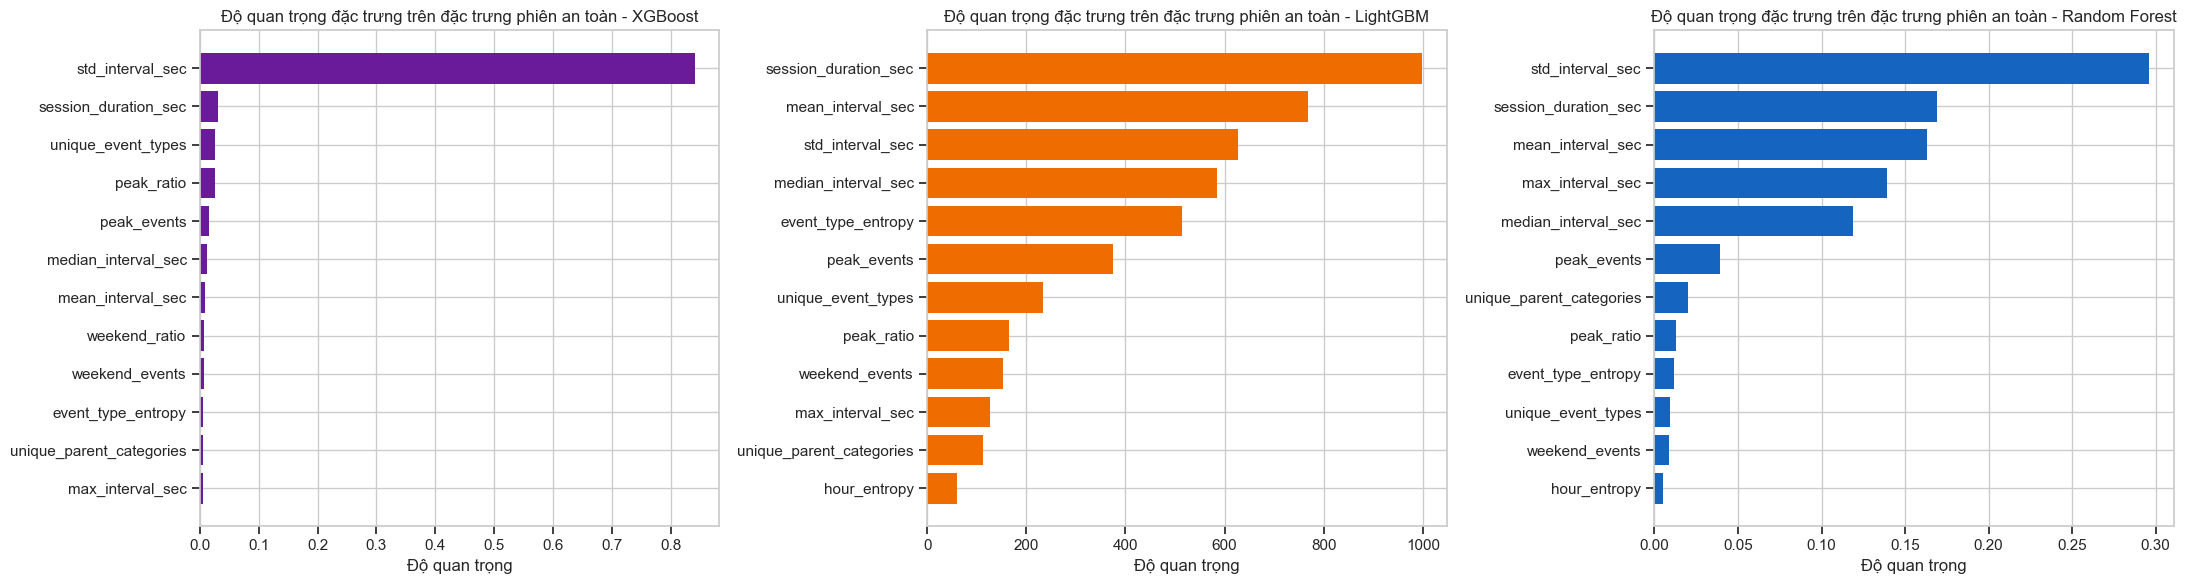

,feature,importance,model
0,std_interval_sec,0.840691,XGBoost
1,session_duration_sec,0.031269,XGBoost
2,unique_event_types,0.026589,XGBoost
3,peak_ratio,0.026102,XGBoost
4,peak_events,0.015749,XGBoost
5,median_interval_sec,0.012863,XGBoost
6,mean_interval_sec,0.008968,XGBoost
7,weekend_ratio,0.007783,XGBoost
8,weekend_events,0.006845,XGBoost
9,event_type_entropy,0.006225,XGBoost


In [47]:
def top_feature_importances(model, feature_names, model_name, top_n=12):
    frame = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_, 'model': model_name})
    return frame.sort_values('importance', ascending=False).head(top_n)

importance_models = [
    ('XGBoost', xgboost_model, COLORS['secondary']),
    ('LightGBM', lightgbm_model, COLORS['warning']),
    ('Random Forest', random_forest_model, COLORS['primary']),
]
feature_importances = pd.concat(
    [top_feature_importances(model, safe_feature_cols, model_name) for model_name, model, _ in importance_models],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (model_name, _, color) in zip(axes, importance_models):
    subset = feature_importances[feature_importances['model'] == model_name].sort_values('importance', ascending=True)
    ax.barh(subset['feature'], subset['importance'], color=color)
    ax.set_title(f'Độ quan trọng đặc trưng trên đặc trưng phiên an toàn - {model_name}')
    ax.set_xlabel('Độ quan trọng')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

display(feature_importances)

<a id="section-isolation-forest"></a>

## 11. Đức Anh - Isolation Forest

Isolation Forest fit trên train không cần nhãn. Validation dùng để chọn ngưỡng anomaly score, sau đó test dùng để báo cáo overlap với pseudo-label.


Isolation Forest score threshold: chọn ngưỡng=0.5841 trên validation (f1=0.3996, precision=0.2992, recall=0.6016)

Isolation Forest - safe_features - Unsupervised overlap with session pseudo-label - validation
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97    340215
     Anomaly       0.30      0.60      0.40     12271

    accuracy                           0.94    352486
   macro avg       0.64      0.78      0.68    352486
weighted avg       0.96      0.94      0.95    352486


Isolation Forest - safe_features - Unsupervised overlap with session pseudo-label - test
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97    339835
     Anomaly       0.30      0.61      0.40     12491

    accuracy                           0.94    352326
   macro avg       0.64      0.78      0.68    352326
weighted avg       0.96      0.94      0.95    352326



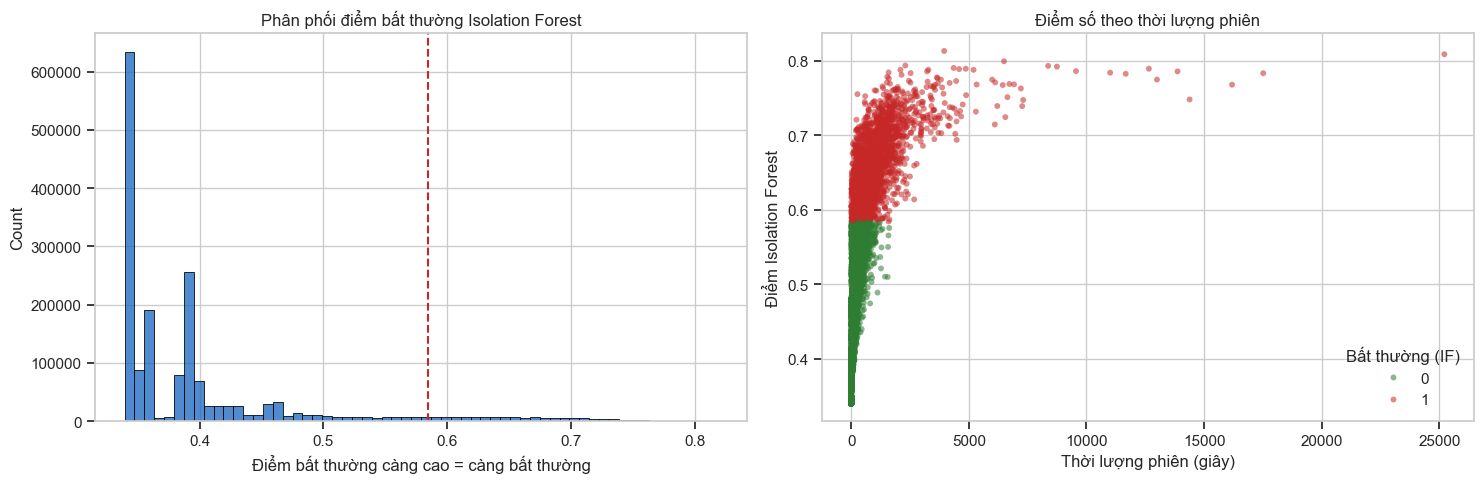

In [48]:
if IFOREST_TRAIN_ROWS is not None and len(train_indices) > IFOREST_TRAIN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    isolation_forest_train_indices = rng.choice(train_indices, size=IFOREST_TRAIN_ROWS, replace=False)
else:
    isolation_forest_train_indices = train_indices

isolation_forest_model = IsolationForest(n_estimators=150, contamination='auto', random_state=RANDOM_STATE, n_jobs=-1)
isolation_forest_model.fit(features_safe_scaled[isolation_forest_train_indices])

isolation_forest_score = -isolation_forest_model.score_samples(features_safe_scaled)
isolation_forest_threshold = choose_best_threshold(labels_validation, isolation_forest_score[validation_indices], 'Isolation Forest score threshold')
isolation_forest_prediction = (isolation_forest_score >= isolation_forest_threshold).astype(int)

sessions['isolation_forest_score'] = isolation_forest_score
sessions['isolation_forest_pred'] = isolation_forest_prediction

record_evaluation(
    'Isolation Forest',
    'safe_features',
    UNSUPERVISED_EVALUATION,
    'validation',
    labels_validation,
    isolation_forest_prediction[validation_indices],
    isolation_forest_score[validation_indices],
    threshold=isolation_forest_threshold,
    store_confusion=False,
)
record_evaluation(
    'Isolation Forest',
    'safe_features',
    UNSUPERVISED_EVALUATION,
    'test',
    labels_test,
    isolation_forest_prediction[test_indices],
    isolation_forest_score[test_indices],
    threshold=isolation_forest_threshold,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(sessions['isolation_forest_score'], bins=60, color=COLORS['primary'], ax=axes[0])
axes[0].axvline(isolation_forest_threshold, color=COLORS['anomaly'], linestyle='--')
axes[0].set_title('Phân phối điểm bất thường Isolation Forest')
axes[0].set_xlabel('Điểm bất thường càng cao = càng bất thường')

plot_sample = sessions.sample(min(PLOT_SAMPLE_ROWS, len(sessions)), random_state=RANDOM_STATE)
sns.scatterplot(data=plot_sample, x='session_duration_sec', y='isolation_forest_score', hue='isolation_forest_pred', palette={0: COLORS['normal'], 1: COLORS['anomaly']}, alpha=0.55, linewidth=0, s=18, ax=axes[1])
axes[1].set_title('Điểm số theo thời lượng phiên')
axes[1].set_xlabel('Thời lượng phiên (giây)')
axes[1].set_ylabel('Điểm Isolation Forest')
axes[1].legend(title='Bất thường (IF)')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_isolation_scores.png', dpi=160, bbox_inches='tight')
plt.show()

## 11b. Phân loại đa nhãn: dự đoán LOẠI bất thường (multi-label)

Các mô hình ở Mục 7–11 chỉ trả lời **"có bất thường hay không"** (nhị phân). Mục này bổ sung khả năng **dự đoán loại bất thường** trong 12 loại nghiệp vụ (BR01–BR12).

Vì một session có thể đồng thời thuộc **nhiều loại** (ví dụ vừa *Bot scraper* vừa *Rapid-fire*), đây là bài toán **đa nhãn (multi-label)**, không phải multi-class. Ta dùng chiến lược **One-vs-Rest**: huấn luyện 12 bộ phân loại XGBoost nhị phân, mỗi bộ cho một loại, với nhãn lấy từ các cột `flag_BR01..BR12`.

Để kết quả có ý nghĩa (không "chép lại luật"), tất cả mô hình vẫn chỉ dùng **`safe_feature_cols`** — tập đặc trưng hành vi đã loại bỏ các biến trực tiếp sinh ra luật. Do đó F1 sẽ khác nhau theo loại: loại nào để lại "dấu vết hành vi" rõ thì dự đoán tốt, loại bị che hoàn toàn sẽ khó hơn — phản ánh đúng năng lực học thật của mô hình.

Loại::Bot scraper: chọn ngưỡng=0.5000 trên validation (f1=0.8279, precision=0.7064, recall=1.0000)
Loại::Ghost buyer: chọn ngưỡng=0.9490 trên validation (f1=0.1615, precision=0.0919, recall=0.6653)
Loại::Click fraud: chọn ngưỡng=0.7899 trên validation (f1=0.9342, precision=0.8777, recall=0.9985)
Loại::Rapid-fire: chọn ngưỡng=0.9487 trên validation (f1=0.4467, precision=0.3223, recall=0.7277)
Loại::Night crawler: chọn ngưỡng=0.5000 trên validation (f1=0.7212, precision=0.5641, recall=0.9995)
Loại::Item hoarding: chọn ngưỡng=0.9271 trên validation (f1=0.2559, precision=0.1498, recall=0.8785)
Loại::Session bomb: chọn ngưỡng=0.5000 trên validation (f1=0.5739, precision=0.4028, recall=0.9981)
Loại::Sequence violation: chọn ngưỡng=0.8260 trên validation (f1=0.0859, precision=0.0465, recall=0.5616)
Loại::Transaction burst: chọn ngưỡng=0.5000 trên validation (f1=0.3197, precision=0.1919, recall=0.9568)
Loại::Cart abandonment: chọn ngưỡng=0.5000 trên validation (f1=0.0819, precision=0.0430, rec

,anomaly_type,flag,support_test,precision,recall,f1_score,roc_auc,threshold
0,Click fraud,flag_BR03_click_fraud,6319,0.878488,0.996518,0.933788,0.999952,0.789862
1,Night crawler,flag_BR05_night_crawler,6111,0.566265,0.999836,0.723034,0.995078,0.500000
2,Bot scraper,flag_BR01_bot_scraper,2168,0.705078,0.999077,0.826718,0.999974,0.500000
3,Rapid-fire,flag_BR04_rapid_fire,1578,0.323488,0.728771,0.448081,0.992629,0.948694
4,Session bomb,flag_BR07_session_bomb,1022,0.400313,1.000000,0.571748,0.999553,0.500000
5,Item hoarding,flag_BR06_item_hoarding,662,0.162493,0.901813,0.275369,0.993974,0.927067
6,Ghost buyer,flag_BR02_ghost_buyer,471,0.086674,0.651805,0.153003,0.914561,0.948972
7,Transaction burst,flag_BR09_transaction_burst,339,0.221774,0.973451,0.361248,0.997024,0.500000
8,Sequence violation,flag_BR08_sequence_violation,286,0.040364,0.527972,0.074994,0.855510,0.825955
9,Category scanning,flag_BR12_category_scanning,134,0.724324,1.000000,0.840125,0.999998,0.500000


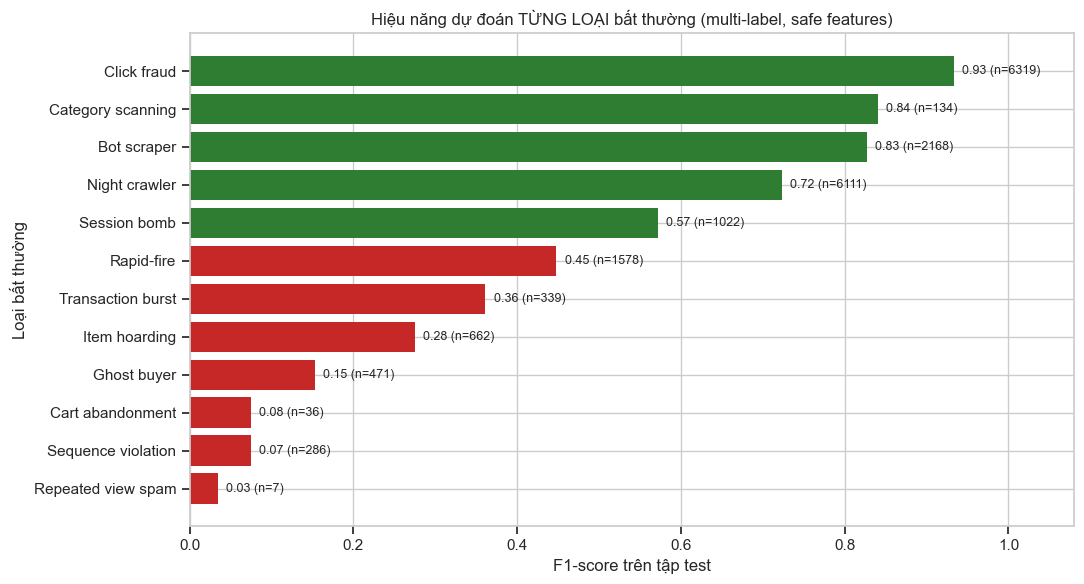


Ví dụ dự đoán loại (so với nhãn luật) trên vài session bất thường:


,anomaly_types,predicted_anomaly_types,predicted_anomaly_type_count
session_id,,,
2_S1,Click fraud,Click fraud,1
51_S1,Click fraud,"Click fraud, Night crawler",2
54_S1,Click fraud,Click fraud,1
97_S1,"Click fraud, Night crawler","Click fraud, Night crawler",2
162_S1,Night crawler,Night crawler,1
172_S2,"Bot scraper, Click fraud, Night crawler, Sessi...","Bot scraper, Click fraud, Night crawler, Sessi...",5
172_S3,"Click fraud, Night crawler","Click fraud, Night crawler",2
172_S4,"Bot scraper, Rapid-fire, Night crawler, Item h...","Bot scraper, Rapid-fire, Night crawler, Item h...",7
224_S1,"Bot scraper, Click fraud, Night crawler","Bot scraper, Click fraud, Night crawler, Sessi...",5


In [49]:
# ============================================================
# 11b. PHÂN LOẠI ĐA NHÃN (MULTI-LABEL) - DỰ ĐOÁN TỪNG LOẠI BẤT THƯỜNG
# ------------------------------------------------------------
# Vấn đề: các mô hình ở trên chỉ trả lời "có bất thường hay không".
# Ở đây ta huấn luyện thêm bộ phân loại đa nhãn để dự đoán session thuộc
# loại bất thường NÀO (12 loại BR01..BR12). Một session có thể thuộc nhiều
# loại cùng lúc -> dùng One-vs-Rest (12 mô hình XGBoost nhị phân).
#
# QUAN TRỌNG: vẫn chỉ dùng safe_feature_cols (đặc trưng hành vi), KHÔNG dùng
# biến trực tiếp tạo ra luật -> mô hình phải HỌC nhận diện loại từ hành vi
# thay vì chép lại luật. Vì vậy F1 khác nhau theo từng loại là điều bình thường.
# ============================================================

y_type_train = sessions[flag_cols].iloc[train_indices]
y_type_validation = sessions[flag_cols].iloc[validation_indices]
y_type_test = sessions[flag_cols].iloc[test_indices]

multilabel_records = []
type_pred_label_cols = []
type_score_all = {}

for flag, type_name in anomaly_type_map.items():
    y_tr = y_type_train[flag].to_numpy().astype(int)
    y_va = y_type_validation[flag].to_numpy().astype(int)
    y_te = y_type_test[flag].to_numpy().astype(int)

    positive_train = int(y_tr.sum())
    negative_train = int((y_tr == 0).sum())
    pred_col = f'pred_{flag}'
    type_pred_label_cols.append(pred_col)

    if positive_train == 0 or negative_train == 0:
        # Train không đủ 2 lớp (loại quá hiếm sau khi tách nhóm) -> gán dự đoán 0
        scores_all = np.zeros(len(sessions), dtype='float32')
        threshold = 0.5
        print(f'[BỎ QUA] {type_name}: train không đủ 2 lớp (positive={positive_train}) -> gán dự đoán 0')
    else:
        scale_pos_weight_type = negative_train / max(positive_train, 1)
        type_model = make_xgboost_model(n_estimators=120, scale_pos_weight=scale_pos_weight_type)
        type_model.fit(features_safe_train, y_tr)
        validation_scores = type_model.predict_proba(features_safe_validation)[:, 1]
        threshold = choose_best_threshold(y_va, validation_scores, f'Loại::{type_name}')
        scores_all = type_model.predict_proba(features_safe)[:, 1].astype('float32')

    type_score_all[flag] = scores_all
    sessions[pred_col] = (scores_all >= threshold).astype(int)

    test_scores = scores_all[test_indices]
    test_predictions = (test_scores >= threshold).astype(int)
    can_compute_auc = 0 < int(y_te.sum()) < len(y_te)
    multilabel_records.append({
        'anomaly_type': type_name,
        'flag': flag,
        'support_test': int(y_te.sum()),
        'precision': precision_score(y_te, test_predictions, zero_division=0),
        'recall': recall_score(y_te, test_predictions, zero_division=0),
        'f1_score': f1_score(y_te, test_predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_te, test_scores) if can_compute_auc else np.nan,
        'threshold': threshold,
    })

# --- Dự đoán LOẠI cho từng session (chuỗi multi-label) ---
predicted_flag_matrix = sessions[type_pred_label_cols].to_numpy(dtype=bool)
sessions['predicted_anomaly_type_count'] = predicted_flag_matrix.sum(axis=1).astype(int)
sessions['predicted_anomaly_types'] = [
    ', '.join(anomaly_type_labels[row_flags].tolist()) if row_flags.any() else 'Normal'
    for row_flags in predicted_flag_matrix
]

# --- Metric tổng hợp đa nhãn trên tập test ---
Y_true_test = y_type_test.to_numpy().astype(int)
Y_pred_test = predicted_flag_matrix[test_indices].astype(int)
micro_f1 = f1_score(Y_true_test, Y_pred_test, average='micro', zero_division=0)
macro_f1 = f1_score(Y_true_test, Y_pred_test, average='macro', zero_division=0)
subset_accuracy = float((Y_true_test == Y_pred_test).all(axis=1).mean())

multilabel_type_metrics = (
    pd.DataFrame(multilabel_records)
    .sort_values('support_test', ascending=False)
    .reset_index(drop=True)
)
multilabel_type_metrics.to_csv(OUTPUT_DIR / 'group_multilabel_type_metrics.csv', index=False)

print('\n' + '=' * 70)
print('KẾT QUẢ PHÂN LOẠI ĐA NHÃN (multi-label) TRÊN TẬP TEST')
print('=' * 70)
print(f'Micro-F1 (gộp toàn bộ 12 loại): {micro_f1:.4f}')
print(f'Macro-F1 (trung bình các loại): {macro_f1:.4f}')
print(f'Subset accuracy (khớp đúng TOÀN BỘ tập loại): {subset_accuracy:.4f}')
display(multilabel_type_metrics)

# --- Biểu đồ F1 theo từng loại ---
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = multilabel_type_metrics.sort_values('f1_score', ascending=True)
bar_colors = [COLORS['anomaly'] if value < 0.5 else COLORS['normal'] for value in plot_df['f1_score']]
ax.barh(plot_df['anomaly_type'], plot_df['f1_score'], color=bar_colors)
for y_pos, (f1_value, support_value) in enumerate(zip(plot_df['f1_score'], plot_df['support_test'])):
    ax.text(min(f1_value + 0.01, 0.98), y_pos, f'{f1_value:.2f} (n={support_value})', va='center', fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel('F1-score trên tập test')
ax.set_ylabel('Loại bất thường')
ax.set_title('Hiệu năng dự đoán TỪNG LOẠI bất thường (multi-label, safe features)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_multilabel_type_f1.png', dpi=160, bbox_inches='tight')
plt.show()

print('\nVí dụ dự đoán loại (so với nhãn luật) trên vài session bất thường:')
example_cols = ['anomaly_types', 'predicted_anomaly_types', 'predicted_anomaly_type_count']
display(sessions.loc[sessions['is_anomaly_rule'] == 1, example_cols].head(10))

## 12. So sánh các thuật toán

Bảng chính dùng `safe_features`. Với supervised models, metric là mức độ khớp với session pseudo-label sau khi giảm leakage. Với unsupervised models, metric là overlap tham khảo với session pseudo-label.

Kết quả được tách thành `validation` và `test`: validation dùng để chọn threshold, test là kết quả báo cáo cuối.

Bảng chỉ số chính trên đặc trưng phiên an toàn / so khớp nhãn giả:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
5,Decision Tree,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.9836,0.9829,0.7889,0.7071,0.7458,0.9881,0.7909,12491,11196
1,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,test,0.5000,0.9313,0.0328,0.0330,0.0329,0.4986,0.0354,12491,12548
21,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,test,0.5841,0.9364,0.3020,0.6060,0.4031,0.9353,0.3472,12491,25061
9,LightGBM,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8590,0.9908,0.8180,0.9507,0.8794,0.9946,0.9423,12491,14517
7,Random Forest,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8601,0.9899,0.8096,0.9349,0.8677,0.9931,0.9188,12491,14425
3,XGBoost,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8845,0.9896,0.8051,0.9311,0.8635,0.9935,0.9289,12491,14445
4,Decision Tree,safe_features,Mô hình giám sát chính so với nhãn giả phiên,validation,0.9836,0.9832,0.7904,0.7051,0.7453,0.9885,0.7900,12271,10947
0,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,validation,0.5000,0.9320,0.0342,0.0350,0.0346,0.4997,0.0348,12271,12555
20,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,validation,0.5841,0.9371,0.2992,0.6016,0.3996,0.9356,0.3404,12271,24674
8,LightGBM,safe_features,Mô hình giám sát chính so với nhãn giả phiên,validation,0.8590,0.9908,0.8207,0.9430,0.8776,0.9944,0.9425,12271,14100


Bảng chỉ số test dùng để báo cáo cuối:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
1,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,test,0.5000,0.9313,0.0328,0.0330,0.0329,0.4986,0.0354,12491,12548
3,XGBoost,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8845,0.9896,0.8051,0.9311,0.8635,0.9935,0.9289,12491,14445
5,Decision Tree,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.9836,0.9829,0.7889,0.7071,0.7458,0.9881,0.7909,12491,11196
7,Random Forest,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8601,0.9899,0.8096,0.9349,0.8677,0.9931,0.9188,12491,14425
9,LightGBM,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8590,0.9908,0.8180,0.9507,0.8794,0.9946,0.9423,12491,14517
21,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,test,0.5841,0.9364,0.3020,0.6060,0.4031,0.9353,0.3472,12491,25061


Bảng phụ: đặc trưng đầy đủ học lại luật phiên:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
15,Decision Tree,full_features,Rule-mimic / agreement with session business r...,test,1.0,0.9972,1.0000,0.9217,0.9593,0.9999,0.9976,12491,11513
13,LightGBM,full_features,Rule-mimic / agreement with session business r...,test,0.5,1.0000,0.9995,0.9995,0.9995,1.0000,1.0000,12491,12491
17,Random Forest,full_features,Rule-mimic / agreement with session business r...,test,0.5,0.9976,0.9373,0.9998,0.9675,1.0000,0.9998,12491,13325
11,XGBoost,full_features,Rule-mimic / agreement with session business r...,test,0.5,0.9999,0.9966,0.9997,0.9982,1.0000,1.0000,12491,12529
14,Decision Tree,full_features,Rule-mimic / agreement with session business r...,validation,1.0,0.9972,1.0000,0.9190,0.9578,0.9999,0.9974,12271,11277
12,LightGBM,full_features,Rule-mimic / agreement with session business r...,validation,0.5,0.9999,0.9994,0.9991,0.9993,1.0000,0.9999,12271,12267
16,Random Forest,full_features,Rule-mimic / agreement with session business r...,validation,0.5,0.9978,0.9401,0.9993,0.9688,1.0000,0.9998,12271,13044
10,XGBoost,full_features,Rule-mimic / agreement with session business r...,validation,0.5,0.9999,0.9967,0.9995,0.9981,1.0000,1.0000,12271,12306


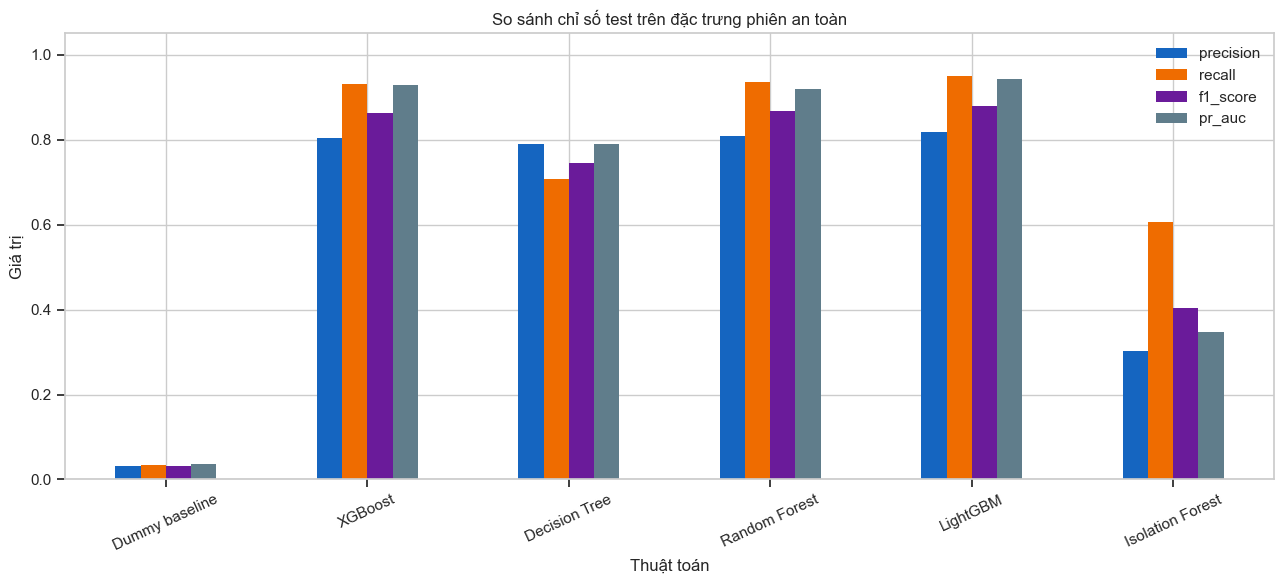

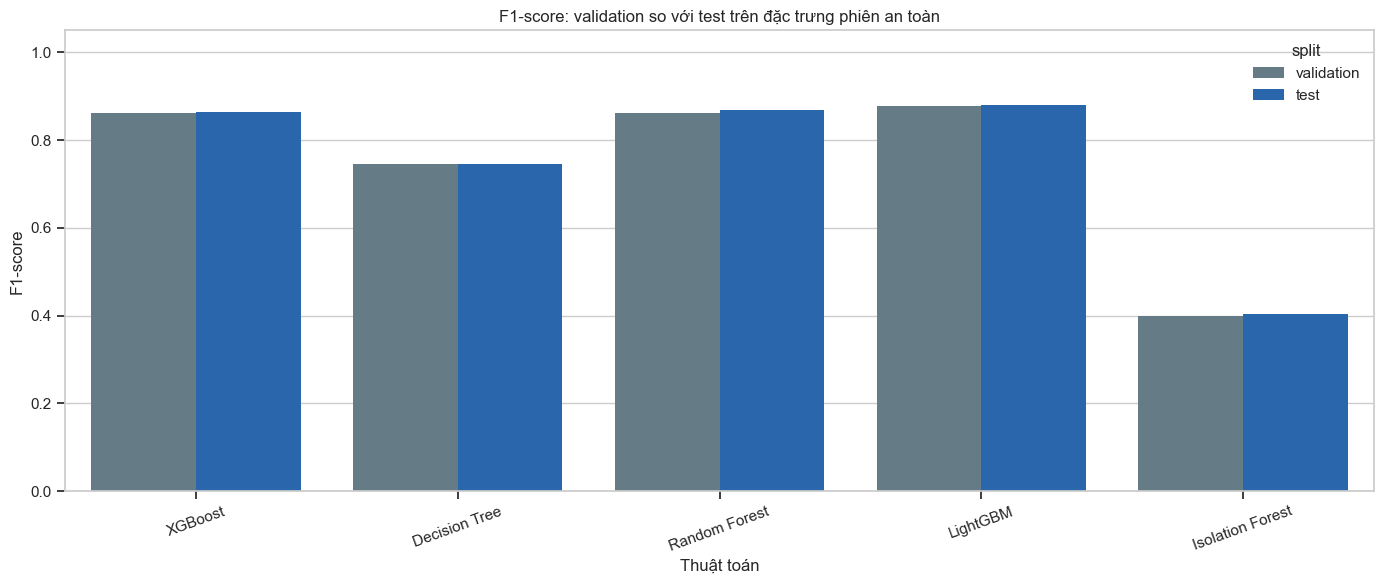

In [50]:
model_metrics = pd.DataFrame(evaluation_records)
metric_columns = ['threshold', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']
model_metrics[metric_columns] = model_metrics[metric_columns].round(4)

main_metrics = model_metrics[
    model_metrics['evaluation_type'].isin([
        BASELINE_EVALUATION,
        MAIN_SUPERVISED_EVALUATION,
        UNSUPERVISED_EVALUATION,
    ])
].copy()
main_test_metrics = main_metrics[main_metrics['split'] == 'test'].copy()
rule_mimic_metrics = model_metrics[
    model_metrics['evaluation_type'] == RULE_MIMIC_EVALUATION
].copy()

print('Bảng chỉ số chính trên đặc trưng phiên an toàn / so khớp nhãn giả:')
display(main_metrics.sort_values(['split', 'model']))
print('Bảng chỉ số test dùng để báo cáo cuối:')
display(main_test_metrics)
print('Bảng phụ: đặc trưng đầy đủ học lại luật phiên:')
display(rule_mimic_metrics.sort_values(['split', 'model']))

fig, ax = plt.subplots(figsize=(13, 6))
plot_metrics = main_test_metrics.set_index('model')[['precision', 'recall', 'f1_score', 'pr_auc']]
plot_metrics.plot(kind='bar', ax=ax, color=[COLORS['primary'], COLORS['warning'], COLORS['secondary'], COLORS['muted']])
ax.set_title('So sánh chỉ số test trên đặc trưng phiên an toàn')
ax.set_xlabel('Thuật toán')
ax.set_ylabel('Giá trị')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

model_order = ['XGBoost', 'Decision Tree', 'Random Forest', 'LightGBM', 'Isolation Forest']
validation_test_plot = main_metrics[main_metrics['model'].isin(model_order)].copy()
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=validation_test_plot, x='model', y='f1_score', hue='split', order=model_order, palette=[COLORS['muted'], COLORS['primary']], ax=ax)
ax.set_title('F1-score: validation so với test trên đặc trưng phiên an toàn')
ax.set_xlabel('Thuật toán')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_validation_test_f1.png', dpi=160, bbox_inches='tight')
plt.show()

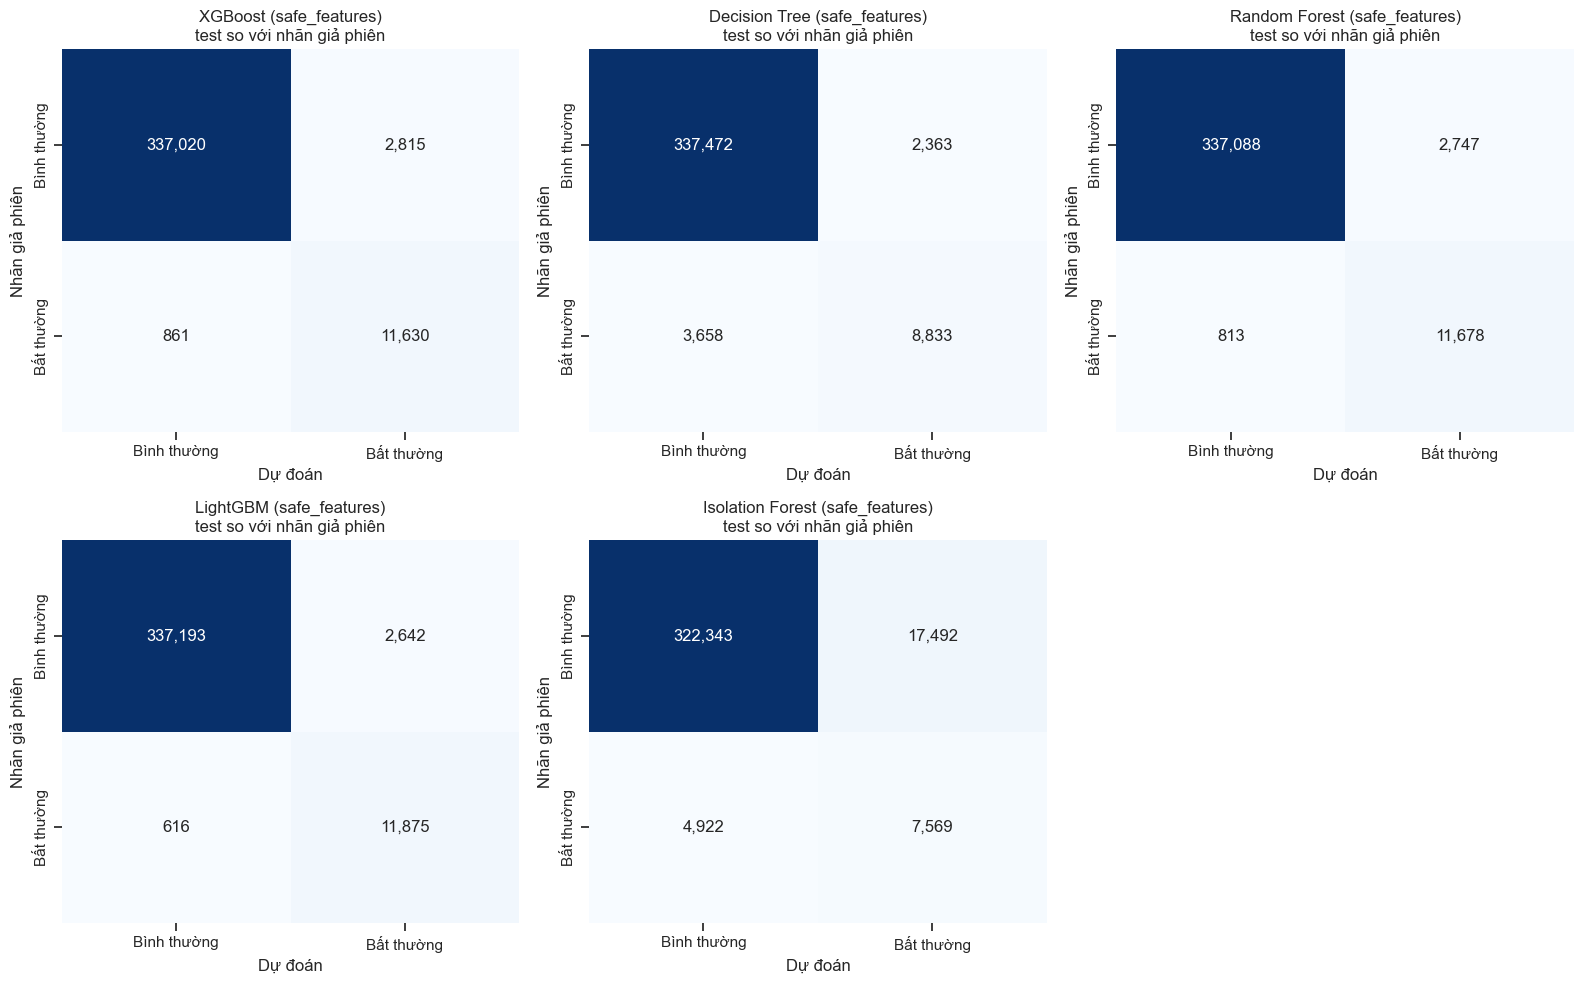

In [51]:
confusion_items = {
    key: value
    for key, value in confusion_prediction_sets.items()
    if key in [
        'XGBoost (safe_features)',
        'Decision Tree (safe_features)',
        'Random Forest (safe_features)',
        'LightGBM (safe_features)',
        'Isolation Forest (safe_features)',
    ]
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (model_name, values) in zip(axes, confusion_items.items()):
    cm = confusion_matrix(values['y_true'], values['y_pred'], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=['Bình thường', 'Bất thường'], yticklabels=['Bình thường', 'Bất thường'], cbar=False, ax=ax)
    ax.set_title(f'{model_name}\n{values["split"]} so với nhãn giả phiên')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Nhãn giả phiên')

for ax in axes[len(confusion_items):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

## 13. Session anomaly report và export

`session_anomaly_tags.csv` là bảng tag rule-level cho mọi session. `session_anomaly_report.csv` là bảng tổng hợp các session bị rule hoặc model đánh dấu.

In [52]:
model_pred_cols = ['xgboost_pred', 'decision_tree_pred', 'random_forest_pred', 'lightgbm_pred', 'isolation_forest_pred']
sessions['model_vote_count'] = sessions[model_pred_cols].sum(axis=1)
sessions['is_rule_anomaly'] = sessions['is_anomaly_rule']
sessions['is_model_anomaly'] = (sessions['model_vote_count'] > 0).astype(int)
sessions['is_anomaly_final'] = ((sessions['is_rule_anomaly'] == 1) | (sessions['is_model_anomaly'] == 1)).astype(int)
sessions['rule_anomaly_types'] = sessions['anomaly_types']
sessions['final_anomaly_reason'] = np.select(
    [
        (sessions['is_rule_anomaly'] == 1) & (sessions['is_model_anomaly'] == 1),
        sessions['is_rule_anomaly'] == 1,
        sessions['is_model_anomaly'] == 1,
    ],
    ['Business rules + ML models', 'Business rules', 'ML model-only suspicious'],
    default='Normal',
)

isolation_forest_score_p99 = sessions['isolation_forest_score'].quantile(0.99)

def classify_severity(row):
    if row['total_flags'] >= 3 or row['model_vote_count'] >= 4 or row['isolation_forest_score'] >= isolation_forest_score_p99:
        return 'CRITICAL'
    if row['total_flags'] >= 2 or row['model_vote_count'] >= 2:
        return 'HIGH'
    if row['total_flags'] == 1 or row['model_vote_count'] == 1:
        return 'MEDIUM'
    return 'LOW'

sessions['severity'] = sessions.apply(classify_severity, axis=1)
severity_order = {'CRITICAL': 3, 'HIGH': 2, 'MEDIUM': 1, 'LOW': 0}
sessions['severity_rank'] = sessions['severity'].map(severity_order)

if not (sessions['anomaly_type_count'] == sessions['total_flags']).all():
    raise ValueError('anomaly_type_count phải bằng total_flags trước khi export')
if not (sessions.loc[sessions['is_rule_anomaly'] == 0, 'rule_anomaly_types'] == 'Normal').all():
    raise ValueError('Session bình thường phải có rule_anomaly_types = Normal trước khi export')

tags_predicted_cols = [col for col in ['predicted_anomaly_types', 'predicted_anomaly_type_count'] if col in sessions.columns]
session_anomaly_tags = sessions[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols + tags_predicted_cols
].reset_index()

report_cols = [
    'visitorid', 'session_number', 'session_start', 'session_end',
    'is_anomaly_final', 'final_anomaly_reason', 'is_rule_anomaly', 'rule_anomaly_types',
    'is_model_anomaly', 'model_vote_count', 'severity', 'anomaly_type_count', 'total_flags',
    'total_events', 'unique_items', 'session_duration_sec', 'events_per_minute',
    'event_type_entropy', 'hour_entropy', 'xgboost_score', 'decision_tree_score',
    'random_forest_score', 'lightgbm_score', 'isolation_forest_score',
] + model_pred_cols + flag_cols
if 'predicted_anomaly_types' in sessions.columns:
    report_cols = report_cols + ['predicted_anomaly_types', 'predicted_anomaly_type_count'] + [
        col for col in sessions.columns if col.startswith('pred_flag_BR')
    ]

session_anomaly_report = (
    sessions[sessions['is_anomaly_final'] == 1]
    .sort_values(['severity_rank', 'model_vote_count', 'total_flags', 'isolation_forest_score'], ascending=[False, False, False, False])
    [report_cols]
    .reset_index()
)

session_anomaly_tags.to_csv(OUTPUT_DIR / 'session_anomaly_tags.csv', index=False)
session_anomaly_report.to_csv(OUTPUT_DIR / 'session_anomaly_report.csv', index=False)
model_metrics.to_csv(OUTPUT_DIR / 'group_model_metrics.csv', index=False)
leakage_audit_df.to_csv(OUTPUT_DIR / 'group_leakage_audit.csv', index=False)
anomaly_type_breakdown.to_csv(OUTPUT_DIR / 'group_anomaly_type_breakdown.csv', index=False)

print(f'Số session trong anomaly report: {len(session_anomaly_report):,}')
print('Đã export: session_anomaly_tags.csv')
print('Đã export: session_anomaly_report.csv')
print('Đã export: group_model_metrics.csv')
print('Đã export: group_leakage_audit.csv')
print('Đã export: group_anomaly_type_breakdown.csv')
if 'multilabel_type_metrics' in dir():
    print('Đã export: group_multilabel_type_metrics.csv (metric dự đoán loại)')
print('\nVí dụ session anomaly report:')
display(session_anomaly_report.head(15))

Số session trong anomaly report: 159,205
Đã export: session_anomaly_tags.csv
Đã export: session_anomaly_report.csv
Đã export: group_model_metrics.csv
Đã export: group_leakage_audit.csv
Đã export: group_anomaly_type_breakdown.csv
Đã export: group_multilabel_type_metrics.csv (metric dự đoán loại)

Ví dụ session anomaly report:


,session_id,visitorid,session_number,session_start,session_end,is_anomaly_final,final_anomaly_reason,is_rule_anomaly,rule_anomaly_types,is_model_anomaly,...,pred_flag_BR03_click_fraud,pred_flag_BR04_rapid_fire,pred_flag_BR05_night_crawler,pred_flag_BR06_item_hoarding,pred_flag_BR07_session_bomb,pred_flag_BR08_sequence_violation,pred_flag_BR09_transaction_burst,pred_flag_BR10_cart_abandonment,pred_flag_BR11_repeated_view_spam,pred_flag_BR12_category_scanning
0,890980_S18,890980,18,2015-07-20 19:26:39.701,2015-07-21 00:48:45.945,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
1,530559_S107,530559,107,2015-07-25 15:28:17.422,2015-07-26 02:17:25.589,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
2,1376763_S2,1376763,2,2015-07-20 19:49:40.822,2015-07-21 02:07:07.124,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
3,286616_S40,286616,40,2015-05-30 21:25:11.588,2015-05-30 23:44:29.087,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
4,152963_S48,152963,48,2015-08-20 19:05:27.399,2015-08-20 22:44:21.935,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
5,861299_S14,861299,14,2015-07-28 20:09:51.405,2015-07-29 01:16:30.736,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
6,1293358_S7,1293358,7,2015-07-28 21:03:28.432,2015-07-29 02:47:41.664,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
7,1150086_S70,1150086,70,2015-07-10 15:19:05.296,2015-07-10 19:10:50.966,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
8,582933_S3,582933,3,2015-07-20 14:47:02.477,2015-07-21 02:53:26.032,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
9,438441_S3,438441,3,2015-06-03 20:37:05.477,2015-06-04 02:46:30.499,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1


## 14. Kết luận báo cáo

- Notebook đã chuyển đơn vị phân tích chính từ `visitorid` sang `session_id` với gap 30 phút.
- Multi-label anomaly tagging hiện hoạt động ở cấp session, phù hợp hơn với hành vi web ngắn hạn như rapid-fire, sequence violation và session bomb.
- Bảng chính dùng safe session features để giảm label leakage; bảng full features chỉ dùng để minh họa rule-mimic.
- Nhóm supervised gồm XGBoost, Decision Tree, Random Forest và LightGBM; LightGBM bổ sung mô hình gradient boosting leaf-wise để so sánh với XGBoost trên dữ liệu bảng.
- Isolation Forest không dùng nhãn khi train; metric của thuật toán này là overlap với session pseudo-label.
- RetailRocket không có nhãn anomaly thật, vì vậy mọi đánh giá định lượng và multi-label tag là pseudo-label do nhóm thiết kế.

In [53]:
print('=' * 70)
print('TỔNG KẾT ĐỒ ÁN NHÓM - CẤP SESSION')
print('=' * 70)
print('Dataset: RetailRocket E-commerce events')
print(f'Số sự kiện: {len(events):,}')
print(f'Số visitor: {events["visitorid"].nunique():,}')
print(f'Số session profile: {len(sessions):,}')
print(f'Bất thường theo business rules: {sessions["is_rule_anomaly"].sum():,} ({sessions["is_rule_anomaly"].mean() * 100:.2f}%)')
print(f'Bất thường theo kết quả tổng hợp: {sessions["is_anomaly_final"].sum():,} ({sessions["is_anomaly_final"].mean() * 100:.2f}%)')
print('\nBảng metric chính:')
display(main_metrics)
print('\nBảng phụ full features học lại luật:')
display(rule_mimic_metrics)
print('\nBreakdown anomaly type:')
display(anomaly_type_breakdown)
print('\nVí dụ multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))
print('\nPhân bố mức độ nghiêm trọng trong report:')
display(session_anomaly_report['severity'].value_counts().rename_axis('severity').reset_index(name='count'))

TỔNG KẾT ĐỒ ÁN NHÓM - CẤP SESSION
Dataset: RetailRocket E-commerce events
Số sự kiện: 2,755,641
Số visitor: 1,407,580
Số session profile: 1,761,675
Bất thường theo business rules: 61,849 (3.51%)
Bất thường theo kết quả tổng hợp: 159,205 (9.04%)

Bảng metric chính:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
0,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,validation,0.5000,0.9320,0.0342,0.0350,0.0346,0.4997,0.0348,12271,12555
1,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,test,0.5000,0.9313,0.0328,0.0330,0.0329,0.4986,0.0354,12491,12548
2,XGBoost,safe_features,Mô hình giám sát chính so với nhãn giả phiên,validation,0.8845,0.9896,0.8051,0.9251,0.8609,0.9938,0.9294,12271,14100
3,XGBoost,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8845,0.9896,0.8051,0.9311,0.8635,0.9935,0.9289,12491,14445
4,Decision Tree,safe_features,Mô hình giám sát chính so với nhãn giả phiên,validation,0.9836,0.9832,0.7904,0.7051,0.7453,0.9885,0.7900,12271,10947
5,Decision Tree,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.9836,0.9829,0.7889,0.7071,0.7458,0.9881,0.7909,12491,11196
6,Random Forest,safe_features,Mô hình giám sát chính so với nhãn giả phiên,validation,0.8601,0.9897,0.8070,0.9272,0.8629,0.9930,0.9195,12271,14100
7,Random Forest,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8601,0.9899,0.8096,0.9349,0.8677,0.9931,0.9188,12491,14425
8,LightGBM,safe_features,Mô hình giám sát chính so với nhãn giả phiên,validation,0.8590,0.9908,0.8207,0.9430,0.8776,0.9944,0.9425,12271,14100
9,LightGBM,safe_features,Mô hình giám sát chính so với nhãn giả phiên,test,0.8590,0.9908,0.8180,0.9507,0.8794,0.9946,0.9423,12491,14517



Bảng phụ full features học lại luật:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
10,XGBoost,full_features,Rule-mimic / agreement with session business r...,validation,0.5,0.9999,0.9967,0.9995,0.9981,1.0000,1.0000,12271,12306
11,XGBoost,full_features,Rule-mimic / agreement with session business r...,test,0.5,0.9999,0.9966,0.9997,0.9982,1.0000,1.0000,12491,12529
12,LightGBM,full_features,Rule-mimic / agreement with session business r...,validation,0.5,0.9999,0.9994,0.9991,0.9993,1.0000,0.9999,12271,12267
13,LightGBM,full_features,Rule-mimic / agreement with session business r...,test,0.5,1.0000,0.9995,0.9995,0.9995,1.0000,1.0000,12491,12491
14,Decision Tree,full_features,Rule-mimic / agreement with session business r...,validation,1.0,0.9972,1.0000,0.9190,0.9578,0.9999,0.9974,12271,11277
15,Decision Tree,full_features,Rule-mimic / agreement with session business r...,test,1.0,0.9972,1.0000,0.9217,0.9593,0.9999,0.9976,12491,11513
16,Random Forest,full_features,Rule-mimic / agreement with session business r...,validation,0.5,0.9978,0.9401,0.9993,0.9688,1.0000,0.9998,12271,13044
17,Random Forest,full_features,Rule-mimic / agreement with session business r...,test,0.5,0.9976,0.9373,0.9998,0.9675,1.0000,0.9998,12491,13325



Breakdown anomaly type:


,anomaly_type,count,percent_sessions
2,Click fraud,31213,1.771780
4,Night crawler,30130,1.710304
0,Bot scraper,10884,0.617821
3,Rapid-fire,8052,0.457065
6,Session bomb,5112,0.290178
5,Item hoarding,3212,0.182326
1,Ghost buyer,2365,0.134247
7,Sequence violation,1573,0.089290
8,Transaction burst,1558,0.088439
11,Category scanning,628,0.035648



Ví dụ multi-label anomaly tagging theo session:


,session_id,visitorid,session_number,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,...,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning,predicted_anomaly_types,predicted_anomaly_type_count
2,2_S1,2,1,1,Click fraud,1,1,0,0,1,...,0,0,0,0,0,0,0,0,Click fraud,1
63,51_S1,51,1,1,Click fraud,1,1,0,0,1,...,0,0,0,0,0,0,0,0,"Click fraud, Night crawler",2
66,54_S1,54,1,1,Click fraud,1,1,0,0,1,...,0,0,0,0,0,0,0,0,Click fraud,1
140,97_S1,97,1,1,"Click fraud, Night crawler",2,2,0,0,1,...,1,0,0,0,0,0,0,0,"Click fraud, Night crawler",2
218,162_S1,162,1,1,Night crawler,1,1,0,0,0,...,1,0,0,0,0,0,0,0,Night crawler,1
234,172_S2,172,2,1,"Bot scraper, Click fraud, Night crawler, Sessi...",4,4,1,0,1,...,1,0,1,0,0,0,0,0,"Bot scraper, Click fraud, Night crawler, Sessi...",5
235,172_S3,172,3,1,"Click fraud, Night crawler",2,2,0,0,1,...,1,0,0,0,0,0,0,0,"Click fraud, Night crawler",2
236,172_S4,172,4,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,4,1,0,0,...,1,1,0,0,0,0,0,0,"Bot scraper, Rapid-fire, Night crawler, Item h...",7
293,224_S1,224,1,1,"Bot scraper, Click fraud, Night crawler",3,3,1,0,1,...,1,0,0,0,0,0,0,0,"Bot scraper, Click fraud, Night crawler, Sessi...",5
336,264_S1,264,1,1,Rapid-fire,1,1,0,0,0,...,0,0,0,0,0,0,0,0,"Rapid-fire, Item hoarding, Sequence violation,...",4



Phân bố mức độ nghiêm trọng trong report:


,severity,count
0,MEDIUM,75520
1,CRITICAL,67506
2,HIGH,16179
